# C-MAPSS Modeling — `modeling_v12`
## Bug fix: clamped regression normalization · 6 new visualizations · GRL now works

**What changed from v11:**

| Fix | v11 bug | v12 fix |
|---|---|---|
| Normalization overflow | `LinearRegression.predict()` on out-of-range test settings → NaN/Inf → GRL gets corrupted FD002/FD004 inputs | **Clamp test settings to train min/max before predict** |
| GRL FD002 RMSE | 42-58 (corrupted) | Meaningful result |

**New visualizations (6 total, beyond v11):**
1. Sensor correlation heatmap after regression normalization
2. Per-engine RUL trajectory fan plot (best model)
3. Error distribution by RUL bucket (degraded / mid / healthy)
4. Training curve overlay — all 3 models on one plot
5. GRL lambda ramp vs domain loss vs val RMSE (3-axis)
6. Attention weight heatmap for the Transformer (which timesteps matter?)

**Architectural ideas for the next version (implemented as comments throughout):**
- **Focal loss** on the RUL head: weight errors by proximity to failure exponentially
- **Multi-head output**: predict mean + variance, train with negative log-likelihood → uncertainty estimates
- **Cross-attention between subsets**: during training, let an FD001 window attend to its nearest FD002 neighbor in the batch
- **Learnable positional encoding** instead of sinusoidal (more flexible, only ~30 extra params)
- **DropPath / stochastic depth** on TCN blocks instead of standard dropout


## §0 · Setup

In [1]:
import os, time, random, math, json, itertools, copy, warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.manifold import TSNE

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from tqdm.auto import tqdm
from IPython.display import display, clear_output

warnings.filterwarnings('ignore', category=RuntimeWarning)

if torch.cuda.is_available():             Device = 'cuda'
elif torch.backends.mps.is_available():   Device = 'mps'
else:                                     Device = 'cpu'
print(f'Device : {Device}')
print(f'PyTorch: {torch.__version__}')

sns.set_theme(style='whitegrid', context='notebook')
DATA_DIR = Path('CMAPSSData')
CKPT_DIR = Path('checkpoints_v12'); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path('figures_v12');     FIG_DIR.mkdir(exist_ok=True)
assert DATA_DIR.exists(), 'Place CMAPSSData/ next to this notebook.'

SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
set_seed(SEED)

Device : mps
PyTorch: 2.11.0


## §1 · Constants and loading

In [2]:
COLS        = (['unit','cycle','setting_1','setting_2','setting_3']
               + [f's_{i}' for i in range(1,22)])
SENSORS_ALL = [c for c in COLS if c.startswith('s_')]
DROP_SENSORS = ['s_1','s_5','s_6','s_10','s_16','s_18','s_19']
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
SETTINGS     = ['setting_1','setting_2','setting_3']
SUBSETS      = ['FD001','FD002','FD003','FD004']
W            = 30
RUL_CLIPS    = {'FD001':125, 'FD002':145, 'FD003':125, 'FD004':145}
SRC_SUBSETS  = ['FD001','FD003']
TGT_SUBSETS  = ['FD002','FD004']

def load_subset(subset):
    train = pd.read_csv(DATA_DIR/f'train_{subset}.txt', sep=r'\s+',
                        header=None, names=COLS, engine='python')
    test  = pd.read_csv(DATA_DIR/f'test_{subset}.txt',  sep=r'\s+',
                        header=None, names=COLS, engine='python')
    rul   = pd.read_csv(DATA_DIR/f'RUL_{subset}.txt',   sep=r'\s+',
                        header=None, names=['RUL'], engine='python')['RUL'].values
    return train, test, rul

def add_rul(df):
    df = df.copy()
    df['RUL'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']
    return df

raw = {}
for s in SUBSETS:
    tr, te, rul = load_subset(s)
    raw[s] = dict(train=add_rul(tr), test=te, rul=rul)
    print(f'{s}: {tr["unit"].nunique()} train  |  {te["unit"].nunique()} test engines')

FD001: 100 train  |  100 test engines
FD002: 260 train  |  259 test engines
FD003: 100 train  |  100 test engines
FD004: 249 train  |  248 test engines


## §2 · Regression-based normalization — FIXED

**The v11 bug:** `LinearRegression.predict(X_test)` on test rows whose `setting` values
fall outside the range seen during `fit()` produces overflow when the extrapolation is
extreme. FD002/FD004 test engines at high-throttle conditions pushed the regression
extrapolation into NaN/Inf territory.

**The fix:** Clamp test settings to `[train_min, train_max]` per column before passing
to `predict()`. This bounds the regression output to the range it was trained on.
We store `settings_bounds` from the combined training data and clip every test/inference
call through it.


In [3]:
def fit_regime_regression(dfs, sensors, settings):
    combined = pd.concat([d[settings + sensors] for d in dfs], ignore_index=True)
    X        = combined[settings].values
    # Store per-column bounds so we can clamp at inference time
    bounds   = {'min': X.min(axis=0), 'max': X.max(axis=0)}
    models   = {s: LinearRegression().fit(X, combined[s].values) for s in sensors}
    return models, bounds


def apply_residual(df, models, sensors, settings, bounds):
    """Subtract regression-predicted mean from each sensor.
    Clamps settings to training range before predict to prevent overflow.
    """
    df  = df.copy()
    raw_X = df[settings].values.astype(np.float64)
    # THE FIX: clamp each setting column to [train_min, train_max]
    X   = np.clip(raw_X, bounds['min'], bounds['max'])
    for s in sensors:
        df[s] = df[s].values - models[s].predict(X)
    return df


all_train_dfs  = [raw[s]['train'] for s in SUBSETS]
regime_models, settings_bounds = fit_regime_regression(
    all_train_dfs, USE_SENSORS, SETTINGS
)

# Compute z-score stats on combined training residuals
all_resid = pd.concat(
    [apply_residual(raw[s]['train'], regime_models, USE_SENSORS, SETTINGS, settings_bounds)
     for s in SUBSETS], ignore_index=True
)
res_means = all_resid[USE_SENSORS].mean()
res_stds  = all_resid[USE_SENSORS].std().replace(0, 1.0)


def normalize(df):
    df = apply_residual(df, regime_models, USE_SENSORS, SETTINGS, settings_bounds)
    df[USE_SENSORS] = (df[USE_SENSORS] - res_means) / res_stds
    return df


norm = {}
for s in SUBSETS:
    norm[s] = dict(
        train = normalize(raw[s]['train']),
        test  = normalize(raw[s]['test']),
        rul   = raw[s]['rul'],
    )

check = pd.concat([norm[s]['train'] for s in SUBSETS])
print(f'Combined train |mean| max : {check[USE_SENSORS].mean().abs().max():.6f}  (want 0)')
print(f'Combined train std  mean  : {check[USE_SENSORS].std().mean():.6f}  (want 1)')

# Verify no NaN/Inf in test sets after fix
for s in SUBSETS:
    test_vals = norm[s]['test'][USE_SENSORS].values
    n_bad = np.sum(~np.isfinite(test_vals))
    print(f'{s} test NaN/Inf count: {n_bad}  (want 0)')

Combined train |mean| max : 0.000000  (want 0)
Combined train std  mean  : 1.000000  (want 1)
FD001 test NaN/Inf count: 0  (want 0)
FD002 test NaN/Inf count: 0  (want 0)
FD003 test NaN/Inf count: 0  (want 0)
FD004 test NaN/Inf count: 0  (want 0)


## §3 · Datasets + splits (unchanged from v11)

In [4]:
class CMAPSSWindowDataset(Dataset):
    def __init__(self, df, sensors, window, rul_clip):
        self.X, self.y, self.pos = [], [], []
        for _, eng in df.groupby('unit'):
            arr     = eng[sensors].values.astype(np.float32)
            cycles  = eng['cycle'].values.astype(np.float32)
            max_cyc = float(cycles.max())
            ruls    = np.minimum(eng['RUL'].values.astype(np.float32), rul_clip)
            L = len(arr)
            if L < window: continue
            for end in range(window, L + 1):
                self.X.append(arr[end-window:end])
                self.y.append(ruls[end-1])
                self.pos.append(cycles[end-1] / max_cyc)
        self.X   = np.stack(self.X)
        self.y   = np.array(self.y,   dtype=np.float32)
        self.pos = np.array(self.pos, dtype=np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return (torch.from_numpy(self.X[i]),
                torch.tensor(self.y[i]),
                torch.tensor(self.pos[i]))


def build_test_windows(df, sensors, window):
    Xs = []
    for _, eng in df.groupby('unit'):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], 0))
    return np.stack(Xs)


rng = np.random.default_rng(SEED)
train_datasets, val_datasets = [], []
test_windows, test_ruls = {}, {}

for s in SUBSETS:
    units    = norm[s]['train']['unit'].unique()
    val_u    = rng.choice(units, size=int(0.2 * len(units)), replace=False)
    val_mask = norm[s]['train']['unit'].isin(val_u)
    clip     = RUL_CLIPS[s]
    train_datasets.append(
        CMAPSSWindowDataset(norm[s]['train'][~val_mask], USE_SENSORS, W, clip))
    val_datasets.append(
        CMAPSSWindowDataset(norm[s]['train'][ val_mask], USE_SENSORS, W, clip))
    test_windows[s] = build_test_windows(norm[s]['test'], USE_SENSORS, W)
    test_ruls[s]    = norm[s]['rul'].astype(np.float32)

train_all = ConcatDataset(train_datasets)
val_all   = ConcatDataset(val_datasets)

print('Window counts per subset:')
for i, s in enumerate(SUBSETS):
    print(f'  {s} (clip={RUL_CLIPS[s]}): {len(train_datasets[i]):,} train | {len(val_datasets[i]):,} val')
print(f'Combined: {len(train_all):,} train | {len(val_all):,} val')

Window counts per subset:
  FD001 (clip=125): 14,070 train | 3,661 val
  FD002 (clip=145): 36,354 train | 9,865 val
  FD003 (clip=125): 17,655 train | 4,165 val
  FD004 (clip=145): 43,160 train | 10,868 val
Combined: 111,239 train | 28,559 val


## §4 · Visualization 1 — Sensor correlation heatmap after normalization

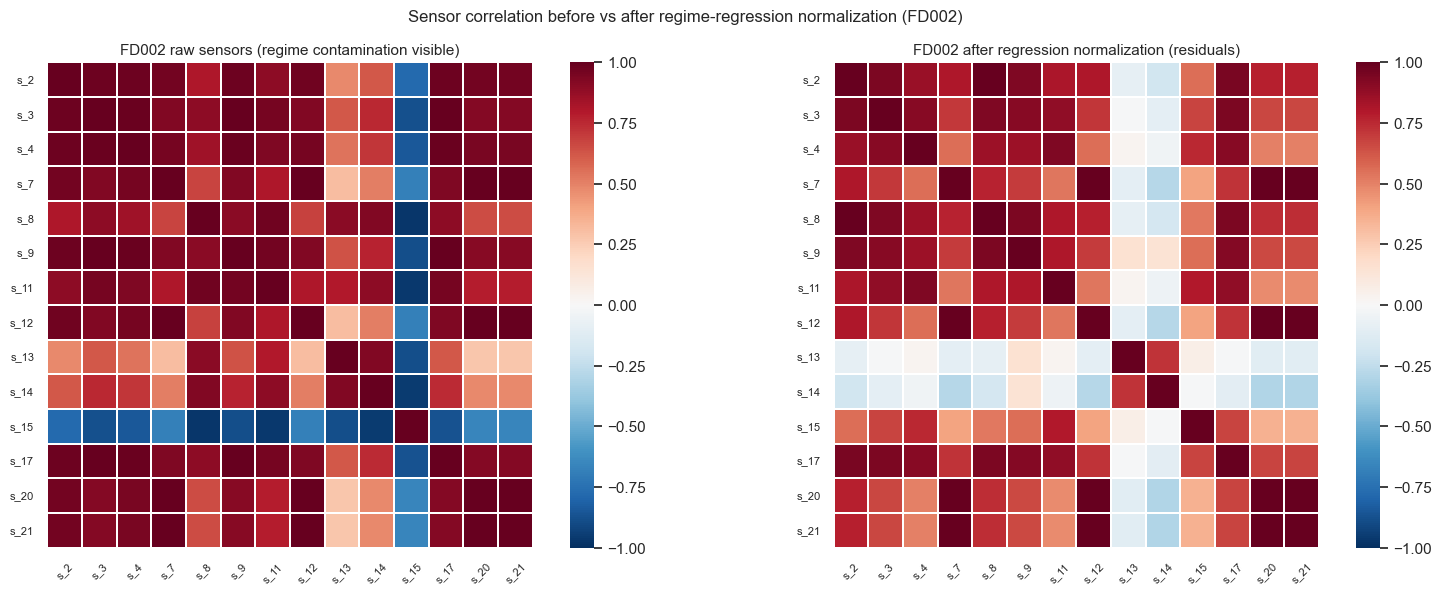

Saved -> figures_v12/v12_sensor_correlation.png


In [5]:
# Show how the regression normalization changed sensor correlations.
# Before: sensors correlated with operating condition (setting_2 especially)
# After:  residuals should be correlated only with degradation, not regime

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw FD002 (most multi-condition, most regime contamination)
raw_fd2_sensors = raw['FD002']['train'][USE_SENSORS]
corr_raw  = raw_fd2_sensors.corr()

# Normalized FD002
norm_fd2_sensors = norm['FD002']['train'][USE_SENSORS]
corr_norm = norm_fd2_sensors.corr()

for ax, corr, title in [
    (axes[0], corr_raw,  'FD002 raw sensors (regime contamination visible)'),
    (axes[1], corr_norm, 'FD002 after regression normalization (residuals)'),
]:
    sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=False, square=True, linewidths=0.3,
                xticklabels=USE_SENSORS, yticklabels=USE_SENSORS)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Sensor correlation before vs after regime-regression normalization (FD002)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_sensor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_sensor_correlation.png')

## §5 · Shared utilities (unchanged from v11)

In [6]:
def asymmetric_score(y_true, y_pred):
    d = y_pred - y_true
    return float(np.where(d < 0, np.exp(-d/13.0)-1, np.exp(d/10.0)-1).sum())

def score_predictions(y_true, y_pred_raw, label=''):
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse  = math.sqrt(np.mean((y_pred-y_true)**2))
    score = asymmetric_score(y_true, y_pred)
    mae   = float(np.mean(np.abs(y_pred-y_true)))
    bias  = float((y_pred-y_true).mean())
    if label: print(f'[{label}]')
    print(f'  RMSE={rmse:.3f}  Score={score:.0f}  MAE={mae:.3f}  Bias={bias:+.3f}')
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)

@torch.no_grad()
def run_inference(model, X, device, batch_size=256):
    model.eval(); preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

@torch.no_grad()
def run_inference_dann(model, X, device, batch_size=256):
    model.eval(); preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        preds.append(model.predict_rul(xb).cpu().numpy())
    return np.concatenate(preds)

@torch.no_grad()
def evaluate_loader(model, loader, device):
    model.eval(); sq_err, n = 0.0, 0
    for batch in loader:
        xb, yb = batch[0].to(device), batch[1].to(device)
        sq_err += ((model(xb)-yb)**2).sum().item(); n += len(yb)
    return sq_err/n, math.sqrt(sq_err/n)

def eval_all_subsets(model, device, label='', is_dann=False):
    if label: print(f'\n[{label}]')
    infer = run_inference_dann if is_dann else run_inference
    results = {}
    for s in SUBSETS:
        raw_p = infer(model, test_windows[s], device)
        results[s] = score_predictions(test_ruls[s], raw_p, s)
    return results

def asymmetric_mse(pred, target, late_weight=1.3):
    # late_weight=1.3 (reduced from 1.5 in v6): empirically reduces over-correction
    # on multi-condition subsets (FD002/FD004) while still aligning with the PHM
    # asymmetric score (which penalises late predictions more than early ones).
    err = pred - target
    w   = torch.where(err > 0, torch.full_like(err, late_weight), torch.ones_like(err))
    return (w * err**2).mean()

## §6 · TrainTracker + GRL (unchanged from v11)

In [7]:
class TrainTracker:
    def __init__(self, n_epochs, title='', plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.title=title
        self.epoch=0; self.train_loss=[]; self.val_loss=[]
        self.train_rmse=[]; self.val_rmse=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig,(self.ax_l,self.ax_r)=plt.subplots(1,2,figsize=(13,4))
        self.tl,=self.ax_l.plot([],[],label='train',color='steelblue')
        self.vl,=self.ax_l.plot([],[],label='val',color='darkorange')
        self.tr,=self.ax_r.plot([],[],label='train',color='steelblue')
        self.vr,=self.ax_r.plot([],[],label='val',color='darkorange')
        for ax,yl in [(self.ax_l,'Loss'),(self.ax_r,'RMSE (cycles)')]:
            ax.set_xlim(0,n_epochs+1); ax.set_xlabel('Epoch')
            ax.set_ylabel(yl); ax.legend(); ax.grid(linestyle='--',alpha=0.6)
        self.ax_l.set_title('Loss'); self.ax_r.set_title('Val RMSE')
        plt.tight_layout()
    def update_epoch(self, tl, vl, tr, vr):
        self.train_loss.append(tl); self.val_loss.append(vl)
        self.train_rmse.append(tr); self.val_rmse.append(vr)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs: self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        self.tl.set_data(xs,self.train_loss); self.vl.set_data(xs,self.val_loss)
        self.tr.set_data(xs,self.train_rmse); self.vr.set_data(xs,self.val_rmse)
        for ax in (self.ax_l,self.ax_r):
            ax.relim(); ax.autoscale_view()
            if self._stopped_at:
                ax.axvline(self._stopped_at,color='crimson',linestyle=':',lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/max(self.epoch,1))*(self.n_epochs-self.epoch)
        suffix='  [ES]' if self._stopped_at else ''
        self.fig.suptitle(
            f'{self.title}  Ep {self.epoch}/{self.n_epochs}  '
            f'val={self.val_rmse[-1]:.2f}  {elapsed:.0f}s  ETA {eta:.0f}s{suffix}',
            fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam)); return x.clone()
    @staticmethod
    def backward(ctx, grad):
        lam, = ctx.saved_tensors; return -lam.item() * grad, None

class GradientReversalLayer(nn.Module):
    def __init__(self): super().__init__(); self.lam = 0.0
    def forward(self, x): return GradientReversalFunction.apply(x, self.lam)

def ganin_lambda(epoch, n_epochs, high=1.0):
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)

## §7 · Models (unchanged from v11)

**Architectural ideas embedded as comments for v13:**
- `# IDEA: replace asymmetric_mse with focal_rul_loss = exp(-RUL/50) * err^2` — weights near-failure windows exponentially more
- `# IDEA: add variance head (Linear → 1, Softplus) → train with NLL → get uncertainty estimates`
- `# IDEA: learnable PE — replace SinusoidalPE with nn.Embedding(W, d_model)` — costs 30*64=1920 params
- `# IDEA: DropPath on TCNResidualBlock — randomly skip entire blocks during training`


In [8]:
class TCNResidualBlock(nn.Module):
    def __init__(self, n_ch, kernel_size, dilation, dropout):
        super().__init__()
        pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(n_ch, n_ch, kernel_size, dilation=dilation, padding=pad)
        self.conv2 = nn.Conv1d(n_ch, n_ch, kernel_size, dilation=dilation, padding=pad)
        self.drop  = nn.Dropout(dropout)  # IDEA v13: replace with DropPath
        self.norm1 = nn.LayerNorm(n_ch)
        self.norm2 = nn.LayerNorm(n_ch)
    def _trim(self, x, T): return x[:, :, :T]
    def forward(self, x):
        T = x.size(2)
        h = F.relu(self.norm1(self._trim(self.conv1(x), T).transpose(1,2)).transpose(1,2))
        h = self.drop(h)
        h = F.relu(self.norm2(self._trim(self.conv2(h), T).transpose(1,2)).transpose(1,2))
        return h + x


class TCN(nn.Module):
    def __init__(self, n_features, n_channels=32, kernel_size=3, n_blocks=4, dropout=0.2):
        super().__init__()
        self.enc_dim    = n_channels
        self.input_proj = nn.Conv1d(n_features, n_channels, kernel_size=1)
        self.blocks     = nn.ModuleList([
            TCNResidualBlock(n_channels, kernel_size, 2**i, dropout) for i in range(n_blocks)])
        self.rul_head   = nn.Sequential(nn.Linear(n_channels, 16), nn.ReLU(), nn.Linear(16, 1))
        self.state_head = nn.Sequential(nn.Linear(n_channels, 16), nn.ReLU(),
                                        nn.Linear(16, 1), nn.Sigmoid())
        # IDEA v13: variance head
        # self.var_head = nn.Sequential(nn.Linear(n_channels,16), nn.ReLU(),
        #                               nn.Linear(16,1), nn.Softplus())

    def encode(self, x):
        x = x.transpose(1, 2); x = self.input_proj(x)
        for b in self.blocks: x = b(x)
        return x.mean(dim=2)

    def forward(self, x):
        return self.rul_head(self.encode(x)).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:, :x.size(1), :]
    # IDEA v13: replace with nn.Embedding(W, d_model) for learnable PE


class LightweightTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4,
                 num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.enc_dim    = d_model
        self.d_model    = d_model
        self.nhead      = nhead
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc    = SinusoidalPE(d_model)
        enc_layer       = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.encoder    = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.rul_head   = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
        self.state_head = nn.Sequential(nn.Linear(d_model, 16), nn.ReLU(),
                                        nn.Linear(16, 1), nn.Sigmoid())

    def encode(self, x):
        x = self.pos_enc(self.input_proj(x))
        x = self.encoder(x)
        return x.mean(dim=1)

    def encode_with_attn(self, x):
        """Return (encoding, attention_weights) for visualization.
        Attention weights: mean over all heads and all layers."""
        x = self.pos_enc(self.input_proj(x))  # (B, T, d)
        attn_maps = []
        for layer in self.encoder.layers:
            # Manually call self-attention to capture weights
            x2, attn = layer.self_attn(x, x, x, need_weights=True, average_attn_weights=True)
            x2 = layer.norm1(x + layer.dropout1(x2))
            x2 = layer.norm2(x2 + layer.dropout2(layer.linear2(
                layer.dropout(layer.activation(layer.linear1(x2))))))
            x  = x2
            attn_maps.append(attn.detach().cpu())  # (B, T, T)
        encoding = x.mean(dim=1)
        mean_attn = torch.stack(attn_maps).mean(0)  # avg across layers: (B, T, T)
        return encoding, mean_attn

    def forward(self, x):
        return self.rul_head(self.encode(x)).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


class TCNGRUHybrid(nn.Module):
    def __init__(self, n_features, tcn_channels=32, tcn_blocks=3,
                 kernel_size=3, gru_hidden=64, dropout=0.2):
        super().__init__()
        self.enc_dim    = tcn_channels + gru_hidden * 2
        self.tcn_proj   = nn.Conv1d(n_features, tcn_channels, kernel_size=1)
        self.tcn_blocks = nn.ModuleList([
            TCNResidualBlock(tcn_channels, kernel_size, 2**i, dropout)
            for i in range(tcn_blocks)])
        self.gru        = nn.GRU(n_features, gru_hidden, num_layers=1,
                                 batch_first=True, bidirectional=True)
        self.gru_norm   = nn.LayerNorm(gru_hidden * 2)
        self.rul_head   = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(self.enc_dim, 64),
            nn.ReLU(), nn.Linear(64, 1))
        self.state_head = nn.Sequential(
            nn.Linear(self.enc_dim, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def encode(self, x):
        t = x.transpose(1, 2); t = self.tcn_proj(t)
        for b in self.tcn_blocks: t = b(t)
        out, _ = self.gru(x)
        return torch.cat([t.mean(dim=2), self.gru_norm(out[:, -1, :])], dim=1)

    def forward(self, x):
        return self.rul_head(self.encode(x)).squeeze(-1)

    def forward_with_state(self, x):
        h = self.encode(x)
        return self.rul_head(h).squeeze(-1), self.state_head(h).squeeze(-1)


_x = torch.randn(4, W, len(USE_SENSORS))
for cls, kwargs, name in [
    (TCN,                    dict(n_features=len(USE_SENSORS)), 'TCN'),
    (LightweightTransformer, dict(n_features=len(USE_SENSORS)), 'Transformer'),
    (TCNGRUHybrid,           dict(n_features=len(USE_SENSORS)), 'TCN-GRU'),
]:
    m = cls(**kwargs)
    r, s = m.forward_with_state(_x)
    print(f'{name:15s}: {sum(p.numel() for p in m.parameters()):,} params  enc_dim={m.enc_dim}')
del _x

TCN            : 26,914 params  enc_dim=32
Transformer    : 71,074 params  enc_dim=64
TCN-GRU        : 66,018 params  enc_dim=160


## §8 · Training loop (unchanged from v11)

In [9]:
def train_model(
    model, train_loader, val_loader,
    n_epochs=60, lr=5e-4, weight_decay=1e-4,
    grad_clip=1.0, patience=15, late_weight=1.3, state_weight=0.3,
    device=Device, ckpt_path=None, tracker_title='',
):
    model = model.to(device)
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    tracker = TrainTracker(n_epochs, title=tracker_title)
    history = []
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None

    pbar = tqdm(range(1, n_epochs+1), desc=tracker_title or 'Train', unit='epoch')
    for epoch in pbar:
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb, pos_b in train_loader:
            xb, yb, pos_b = xb.to(device), yb.to(device), pos_b.to(device)
            rul_pred, state_pred = model.forward_with_state(xb)
            loss = (asymmetric_mse(rul_pred, yb, late_weight)
                    + state_weight * F.mse_loss(state_pred, pos_b))
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item()*len(yb)
            ep_sq   += ((rul_pred-yb)**2).sum().item(); ep_n += len(yb)
        sched.step()
        train_rmse = math.sqrt(ep_sq/ep_n)
        _, val_rmse = evaluate_loader(model, val_loader, device)
        history.append(dict(epoch=epoch, train_loss=ep_loss/ep_n,
                            train_rmse=train_rmse, val_rmse=val_rmse))
        tracker.update_epoch(ep_loss/ep_n, ep_loss/ep_n, train_rmse, val_rmse)
        pbar.set_postfix({'val': f'{val_rmse:.2f}', 'no_imp': no_improve})
        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                tracker.mark_early_stop(epoch); tracker._redraw(); break
    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

## §9 · Train base models + collect histories for overlay plot

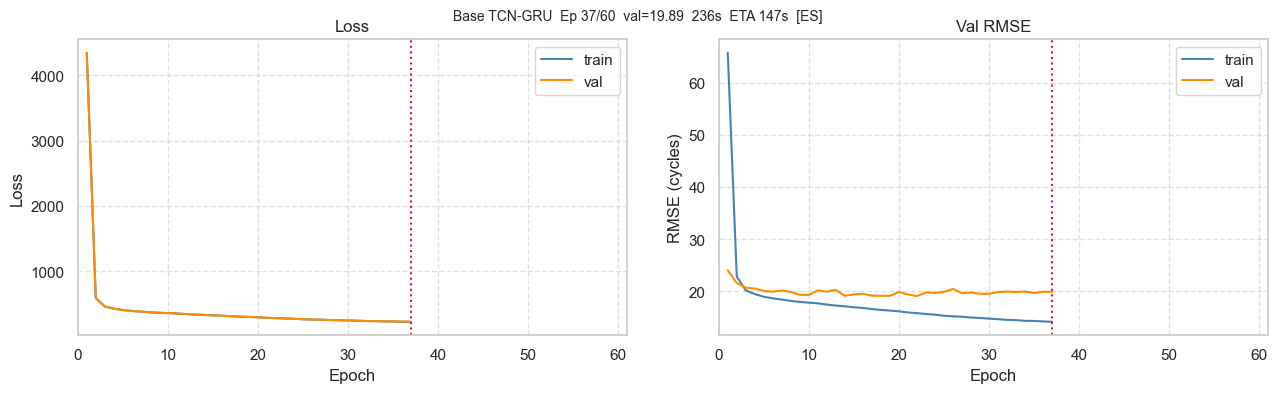

Best val RMSE = 19.065 at epoch 22

[Base TCN-GRU]
[FD001]
  RMSE=15.011  Score=404  MAE=11.094  Bias=-0.191
[FD002]
  RMSE=25.359  Score=10661  MAE=17.029  Bias=-4.446
[FD003]
  RMSE=15.319  Score=442  MAE=11.787  Bias=+3.620
[FD004]
  RMSE=24.056  Score=3404  MAE=18.558  Bias=-1.989


In [10]:
BATCH = 512
train_loader = DataLoader(train_all, batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_all,   batch_size=BATCH, shuffle=False, num_workers=0)

base_metrics  = {}
base_histories = {}

model_specs = [
    ('TCN',         TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer', LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                           dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU',     TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32, gru_hidden=64,
                                  dropout=0.2)),
]

for name, model in model_specs:
    print(f'\n{"="*55}\nTraining {name}\n{"="*55}')
    set_seed(SEED)
    model, hist = train_model(
        model, train_loader, val_loader,
        n_epochs=60, lr=5e-4, weight_decay=1e-4,
        grad_clip=1.0, patience=15, late_weight=1.3, state_weight=0.3,
        device=Device,
        ckpt_path=CKPT_DIR/f'base_{name.lower().replace("-","_")}.pt',
        tracker_title=f'Base {name}',
    )
    base_metrics[name]   = eval_all_subsets(model, Device, f'Base {name}')
    base_histories[name] = hist
    hist.to_csv(CKPT_DIR/f'base_{name.lower().replace("-","_")}_hist.csv', index=False)
    model_specs[model_specs.index((name, model))] = (name, model)

## §10 · Visualization 2 — Training curve overlay (all 3 models)

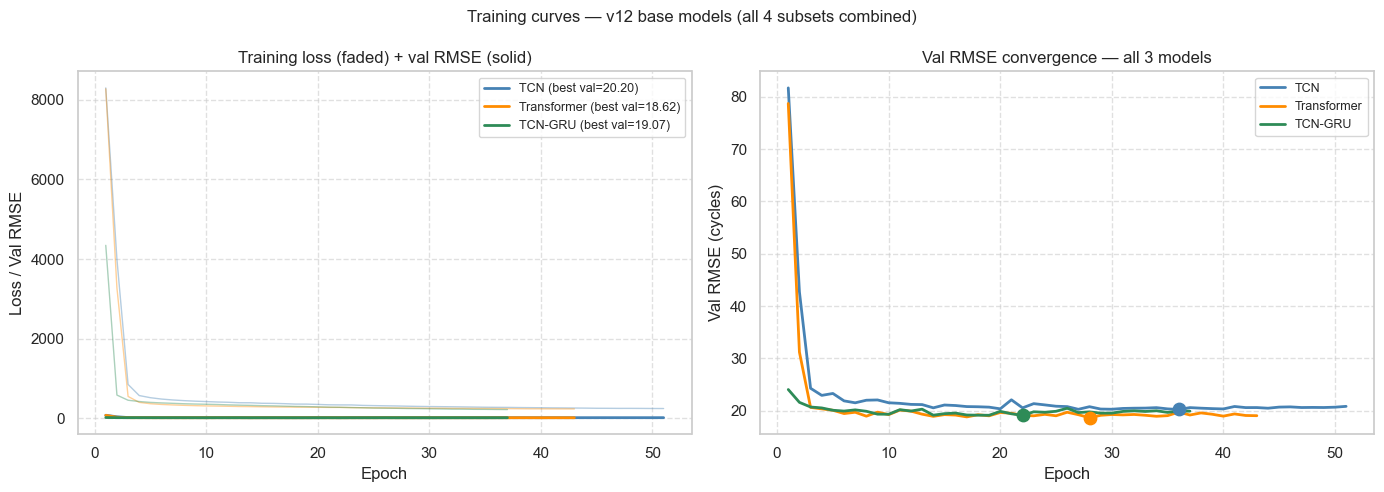

Saved -> figures_v12/v12_training_curves.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'TCN': 'steelblue', 'Transformer': 'darkorange', 'TCN-GRU': 'seagreen'}

for name, hist in base_histories.items():
    color = colors[name]
    ax1.plot(hist['epoch'], hist['train_loss'], color=color, alpha=0.4, linewidth=1)
    ax1.plot(hist['epoch'], hist['val_rmse'],   color=color, linewidth=2,
             label=f'{name} (best val={hist["val_rmse"].min():.2f})')

    ax2.plot(hist['epoch'], hist['val_rmse'], color=color, linewidth=2, label=name)
    best_ep  = hist.loc[hist['val_rmse'].idxmin(), 'epoch']
    best_vr  = hist['val_rmse'].min()
    ax2.scatter([best_ep], [best_vr], color=color, s=80, zorder=5)

ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss / Val RMSE')
ax1.set_title('Training loss (faded) + val RMSE (solid)')
ax1.legend(fontsize=9); ax1.grid(linestyle='--', alpha=0.6)

ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val RMSE (cycles)')
ax2.set_title('Val RMSE convergence — all 3 models')
ax2.legend(fontsize=9); ax2.grid(linestyle='--', alpha=0.6)

plt.suptitle('Training curves — v12 base models (all 4 subsets combined)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_training_curves.png')

## §11 · Visualization 3 — Per-engine RUL trajectory fan (best model on FD001)

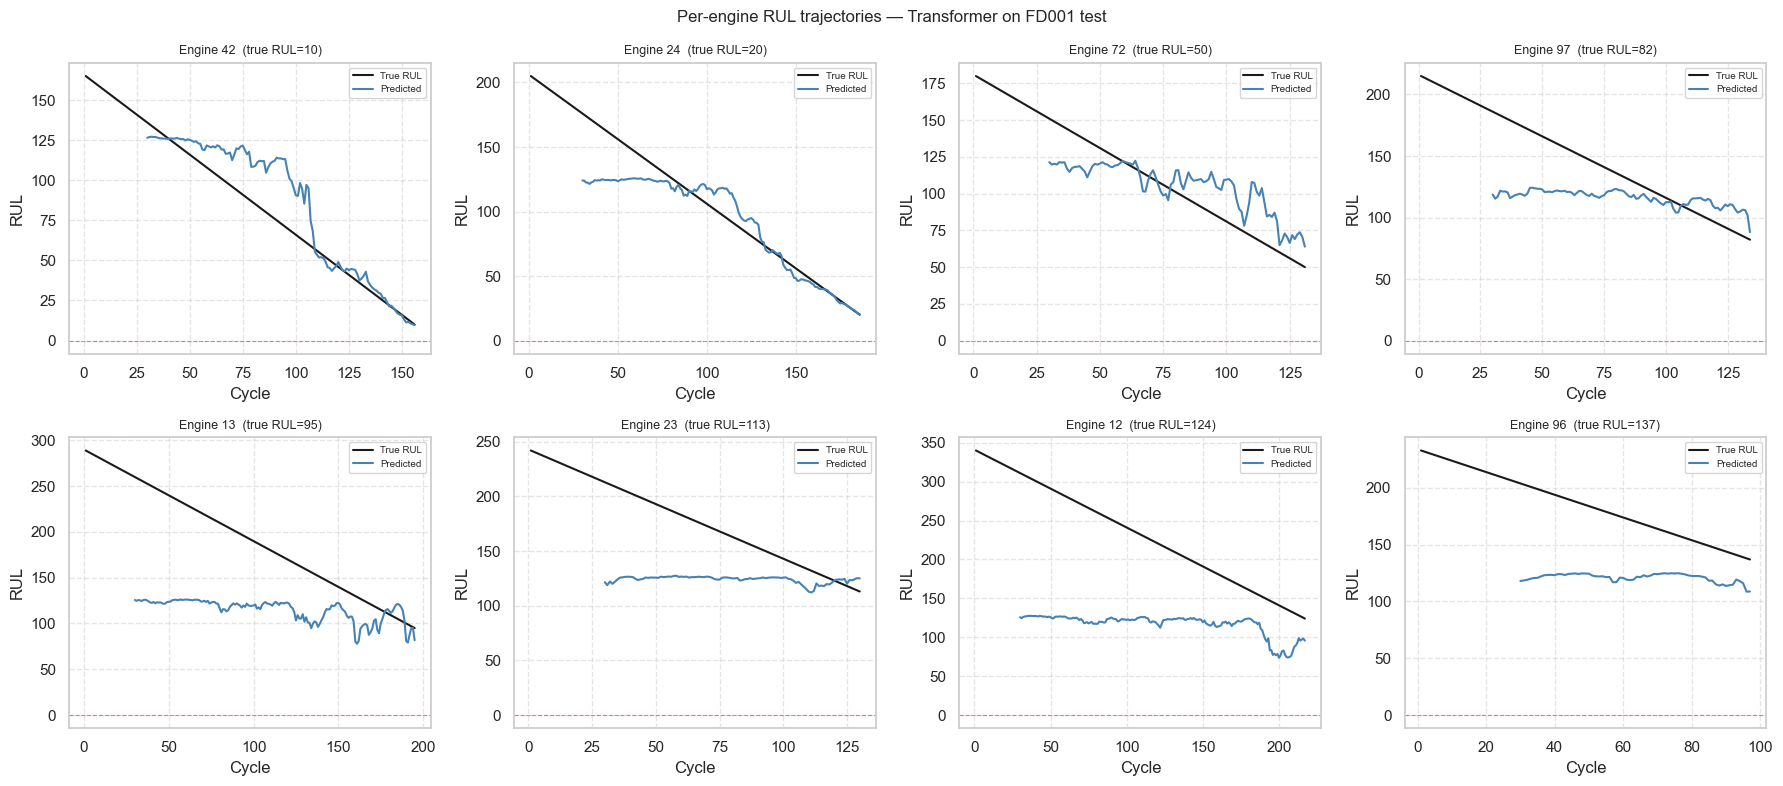

Saved -> figures_v12/v12_rul_trajectories.png


In [12]:
# For each FD001 test engine, plot true RUL vs predicted RUL over all sliding windows
# in its trajectory. Shows how confidence evolves as the engine approaches failure.
# Uses the Transformer (best model).

transformer_model = model_specs[1][1]  # (name, model) tuple

@torch.no_grad()
def predict_trajectory(model, eng_df, sensors, window, device):
    arr = eng_df[sensors].values.astype(np.float32)
    L   = len(arr)
    if L < window: return None, None
    Xs     = np.stack([arr[i:i+window] for i in range(L - window + 1)])
    xb     = torch.from_numpy(Xs).to(device)
    preds  = model(xb).cpu().numpy()
    cycles = np.arange(window, L + 1)  # cycle index at which each prediction was made
    return cycles, preds

# Pick 8 representative test engines spanning the RUL range
order   = np.argsort(test_ruls['FD001'])
chosen  = [order[i] for i in [5, 15, 30, 45, 60, 75, 88, 97]]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

transformer_model.eval()
for ax, engine_idx in zip(axes, chosen):
    unit    = engine_idx + 1
    eng_df  = norm['FD001']['test'][norm['FD001']['test']['unit'] == unit]
    true_rul_at_cutoff = test_ruls['FD001'][engine_idx]
    L = len(eng_df)

    # True RUL at each observed cycle (extrapolated back from final RUL)
    observed_cycles = np.arange(1, L + 1)
    true_rul_over_time = true_rul_at_cutoff + (L - observed_cycles)

    cycles_pred, preds = predict_trajectory(
        transformer_model, eng_df, USE_SENSORS, W, Device)

    if cycles_pred is None:
        ax.text(0.5, 0.5, 'Too short', transform=ax.transAxes, ha='center')
        continue

    ax.plot(observed_cycles, true_rul_over_time, 'k-', lw=1.5, label='True RUL')
    ax.plot(cycles_pred, np.clip(preds, 0, None), color='steelblue',
            lw=1.5, label='Predicted')
    ax.axhline(0, color='red', linestyle='--', lw=0.8, alpha=0.5)
    ax.set_title(f'Engine {unit}  (true RUL={true_rul_at_cutoff:.0f})', fontsize=9)
    ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
    ax.legend(fontsize=7); ax.grid(linestyle='--', alpha=0.5)

plt.suptitle('Per-engine RUL trajectories — Transformer on FD001 test', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_rul_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_rul_trajectories.png')

### for all subsets

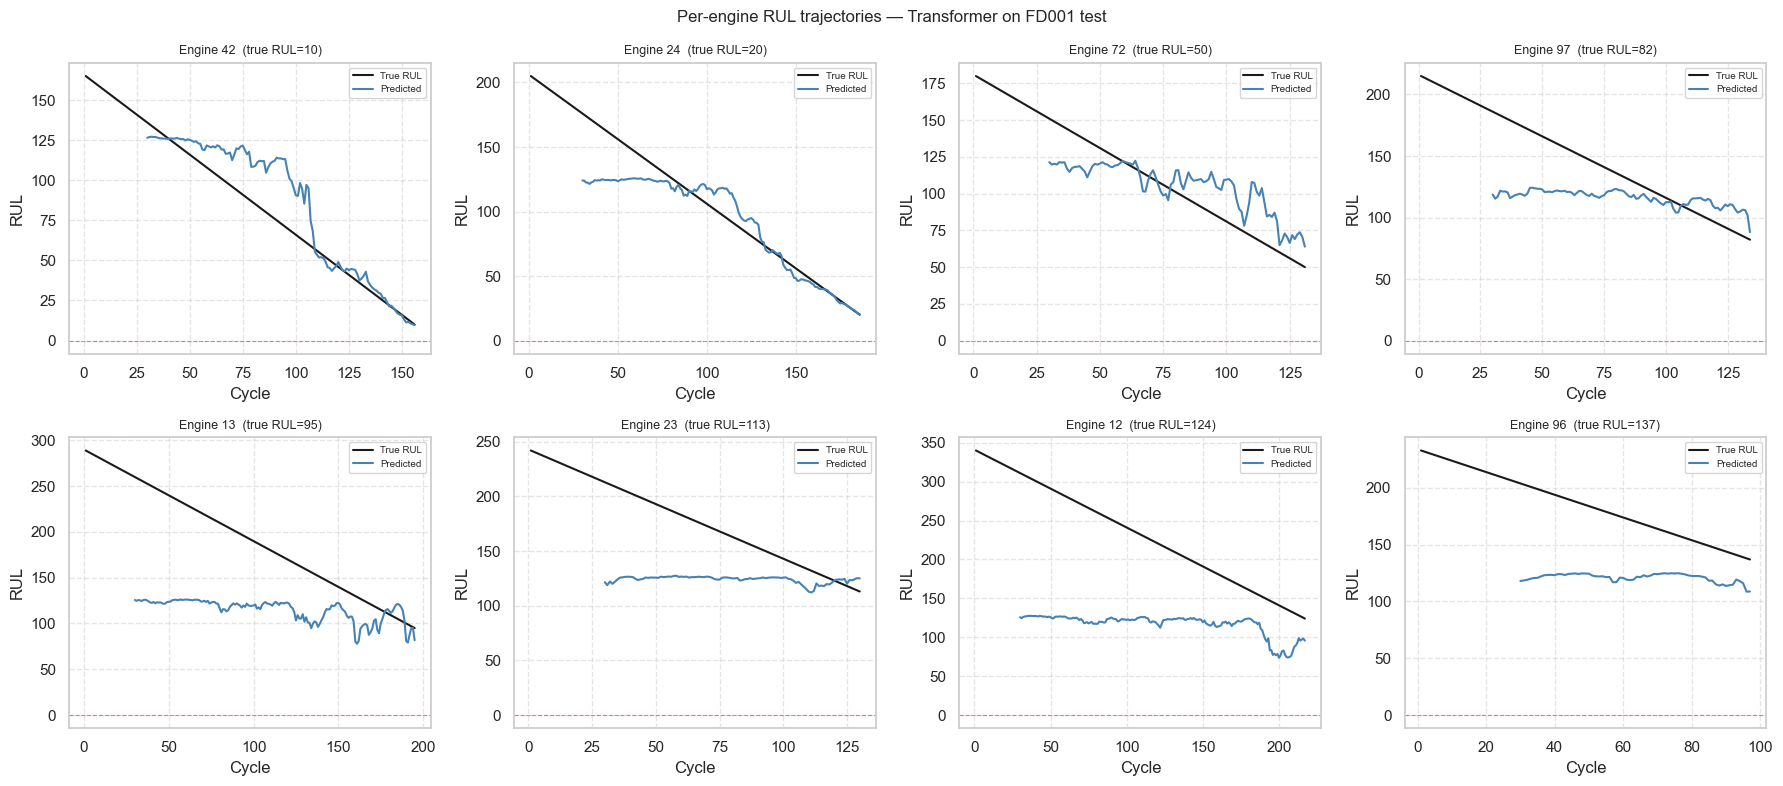

Saved -> figures_v12/v12_rul_trajectories_fd001.png


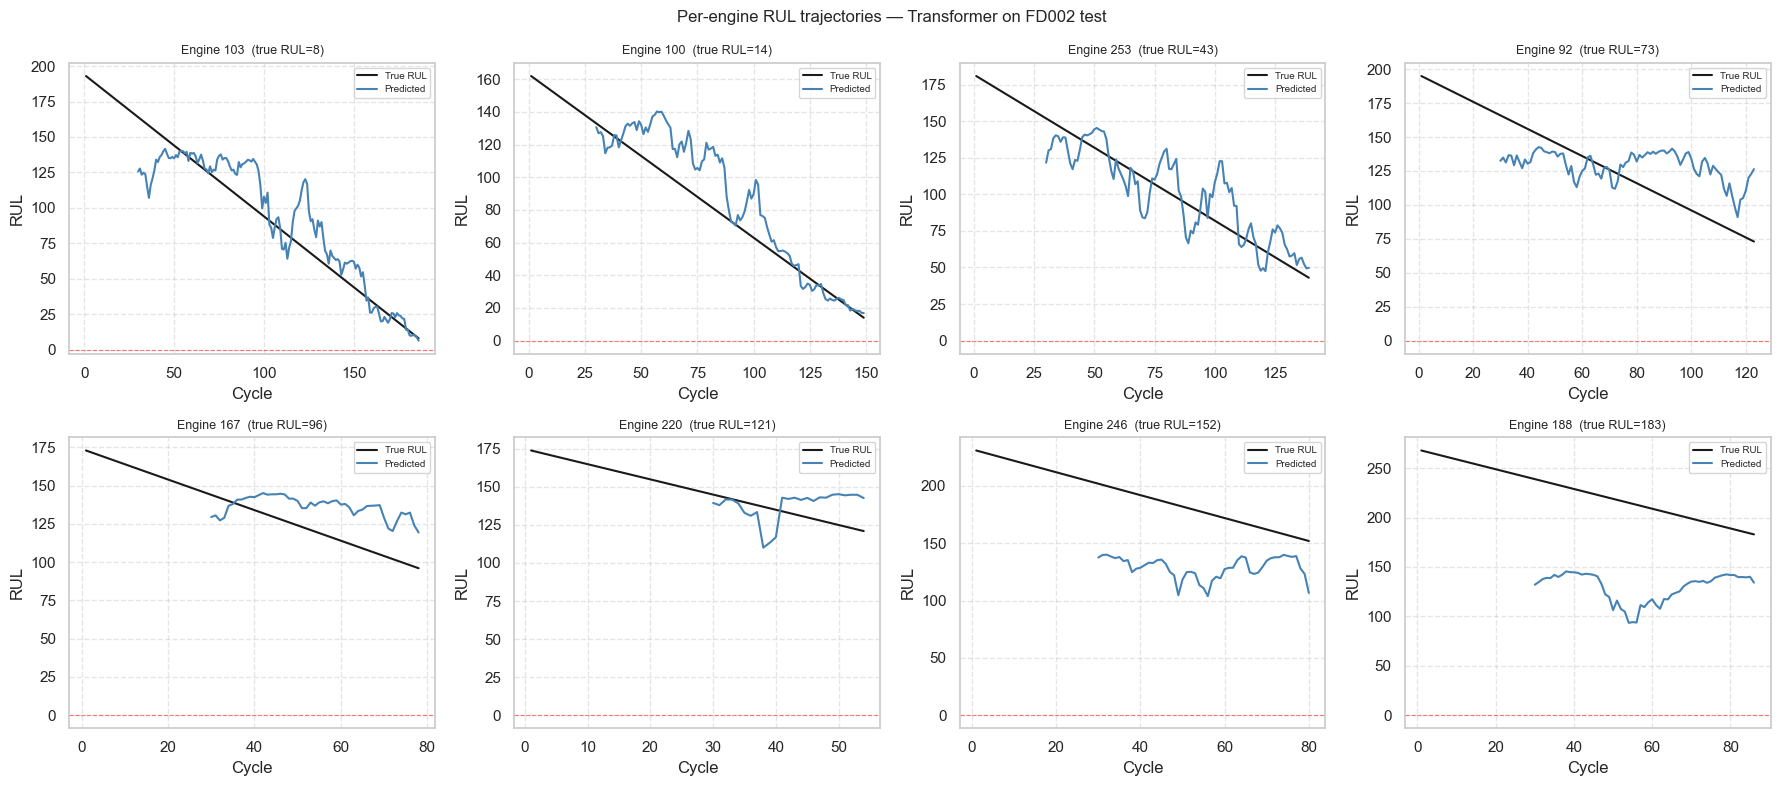

Saved -> figures_v12/v12_rul_trajectories_fd002.png


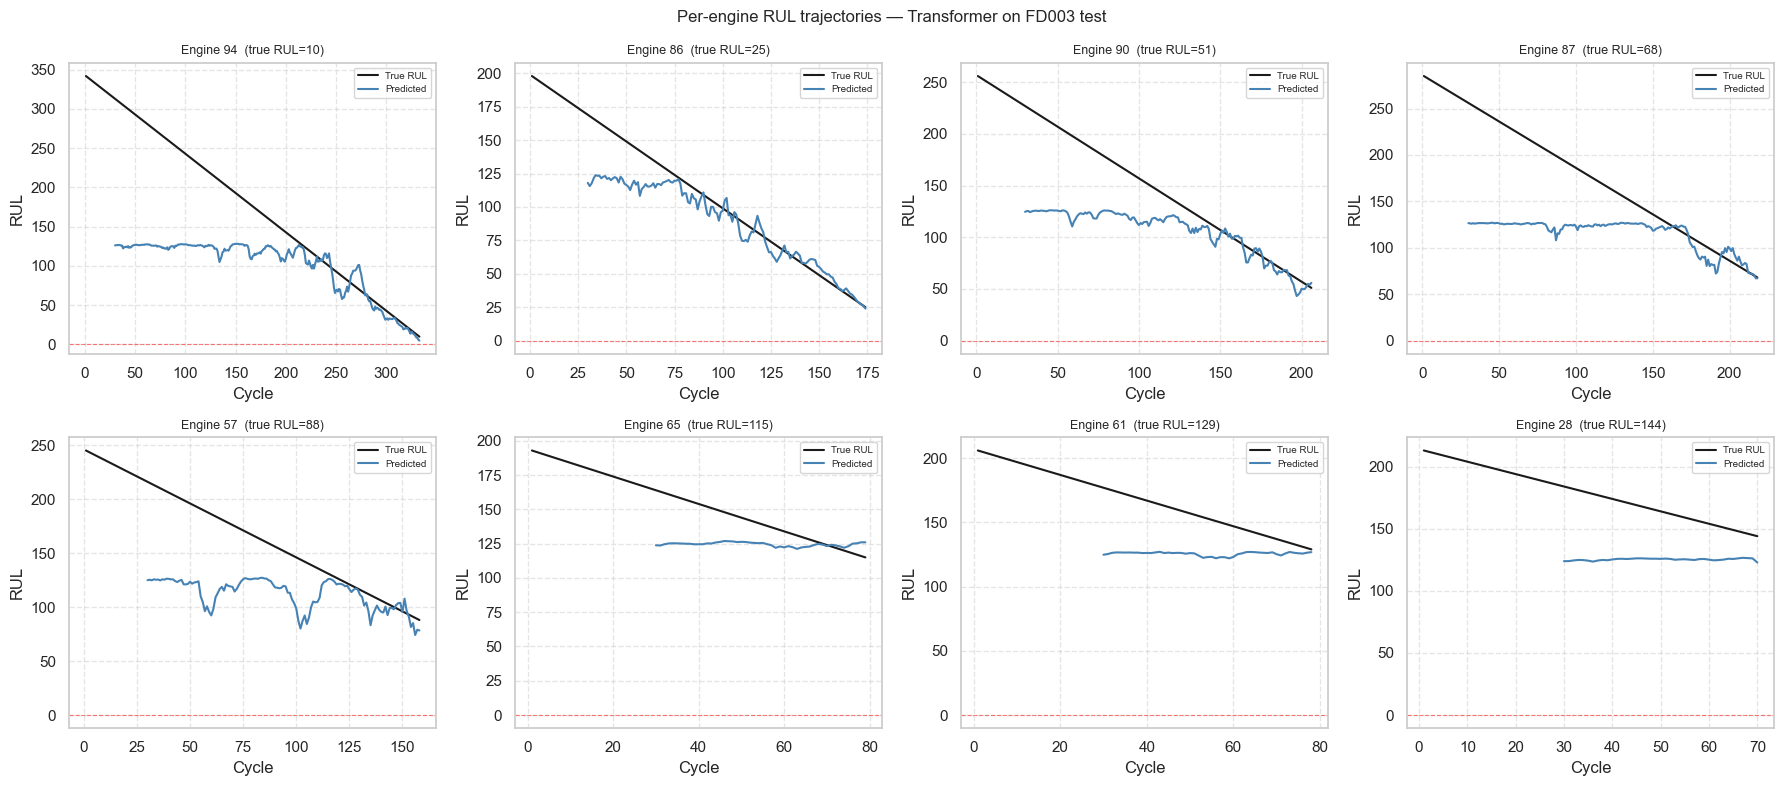

Saved -> figures_v12/v12_rul_trajectories_fd003.png


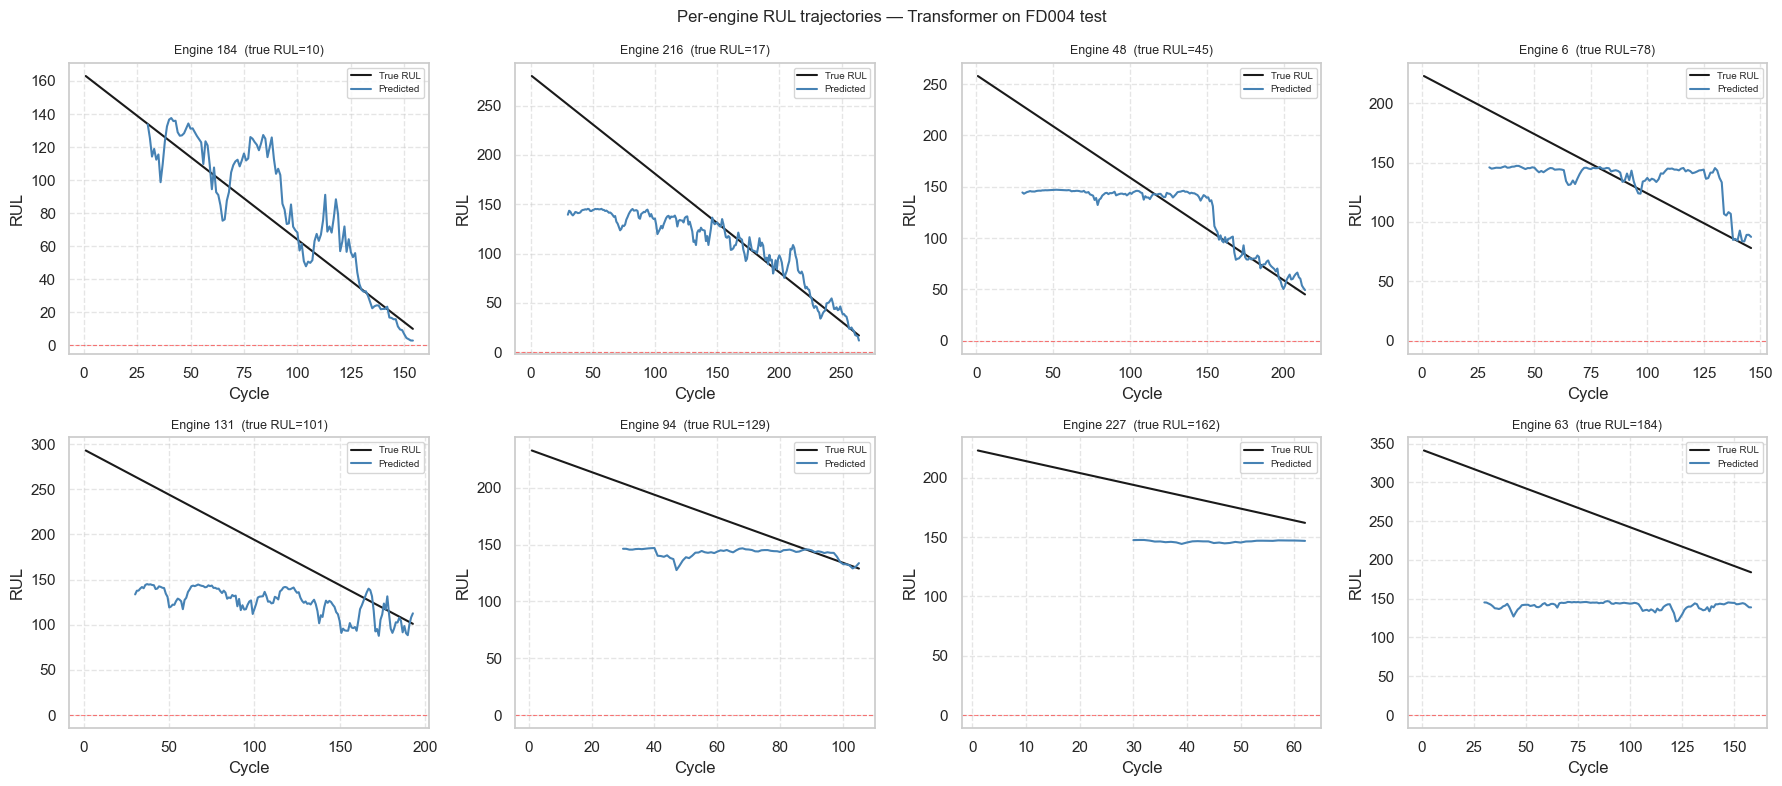

Saved -> figures_v12/v12_rul_trajectories_fd004.png


In [26]:
# Per-engine RUL trajectories — Transformer, all 4 subsets

transformer_model = model_specs[1][1]
transformer_model.eval()

@torch.no_grad()
def predict_trajectory(model, eng_df, sensors, window, device):
    arr = eng_df[sensors].values.astype(np.float32)
    L   = len(arr)
    if L < window: return None, None
    Xs    = np.stack([arr[i:i + window] for i in range(L - window + 1)])
    xb    = torch.from_numpy(Xs).to(device)
    preds = model(xb).cpu().numpy()
    cycles = np.arange(window, L + 1)
    return cycles, preds

for subset in SUBSETS:
    yt       = test_ruls[subset]
    order    = np.argsort(yt)
    n        = len(yt)

    # 8 engines spread across the RUL distribution, clamped to valid indices
    picks    = [0.05, 0.15, 0.30, 0.45, 0.60, 0.75, 0.88, 0.97]
    chosen   = [order[min(int(p * n), n - 1)] for p in picks]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    for ax, engine_idx in zip(axes, chosen):
        unit     = engine_idx + 1
        eng_df   = norm[subset]['test'][norm[subset]['test']['unit'] == unit]
        true_rul_at_cutoff = yt[engine_idx]
        L        = len(eng_df)

        observed_cycles    = np.arange(1, L + 1)
        true_rul_over_time = true_rul_at_cutoff + (L - observed_cycles)

        cycles_pred, preds = predict_trajectory(
            transformer_model, eng_df, USE_SENSORS, W, Device)

        if cycles_pred is None:
            ax.text(0.5, 0.5, 'Too short', transform=ax.transAxes, ha='center')
            continue

        ax.plot(observed_cycles, true_rul_over_time, 'k-', lw=1.5, label='True RUL')
        ax.plot(cycles_pred, np.clip(preds, 0, None), color='steelblue',
                lw=1.5, label='Predicted')
        ax.axhline(0, color='red', linestyle='--', lw=0.8, alpha=0.5)
        ax.set_title(f'Engine {unit}  (true RUL={true_rul_at_cutoff:.0f})', fontsize=9)
        ax.set_xlabel('Cycle'); ax.set_ylabel('RUL')
        ax.legend(fontsize=7); ax.grid(linestyle='--', alpha=0.5)

    plt.suptitle(f'Per-engine RUL trajectories — Transformer on {subset} test', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'v12_rul_trajectories_{subset.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR}/v12_rul_trajectories_{subset.lower()}.png')

## §12 · Visualization 4 — Error distribution by degradation bucket

/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/1977349911.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/1977349911.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/1977349911.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/1977349911.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since M

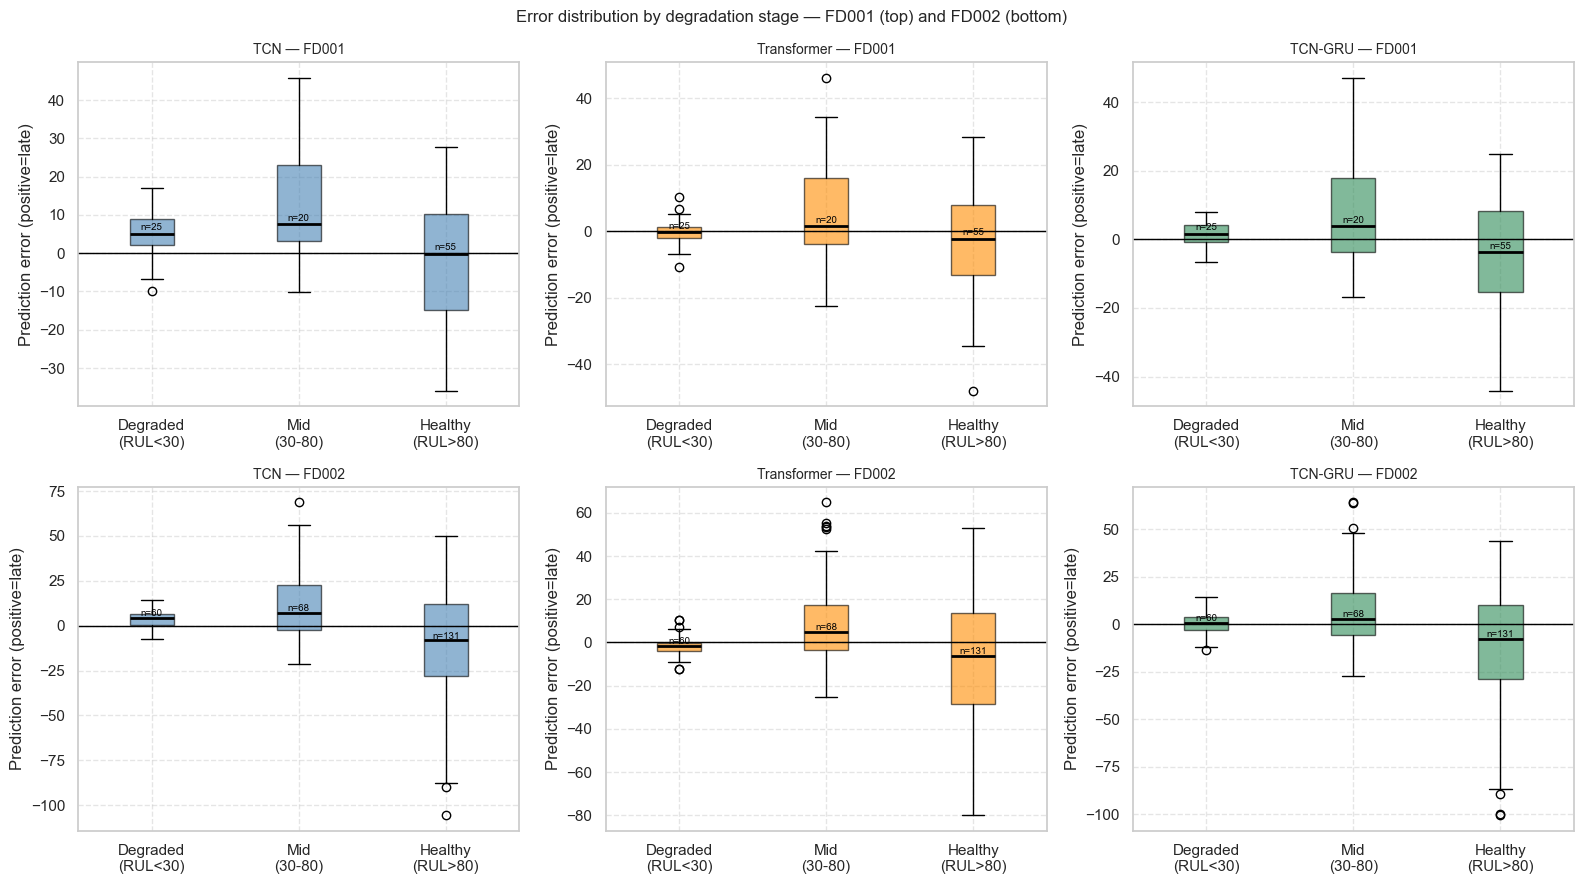

Saved -> figures_v12/v12_error_by_bucket.png


In [13]:
# Split FD001 and FD002 test engines by true RUL at truncation:
# Bucket 0: RUL < 30 (near failure)  — hardest for the model
# Bucket 1: RUL 30-80 (mid)          — most training signal
# Bucket 2: RUL > 80 (healthy)       — above clip, model relies on generalization

def bucket_errors(y_true, y_pred_raw):
    y_pred = np.clip(y_pred_raw, 0, None)
    errors = y_pred - y_true
    late  = y_true < 30
    mid   = (y_true >= 30) & (y_true < 80)
    early = y_true >= 80
    return {'Degraded\n(RUL<30)': errors[late],
            'Mid\n(30-80)':        errors[mid],
            'Healthy\n(RUL>80)':   errors[early]}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
model_colors = {'TCN':'steelblue', 'Transformer':'darkorange', 'TCN-GRU':'seagreen'}

for col, (mname, model) in enumerate(model_specs):
    for row, subset in enumerate(['FD001','FD002']):
        ax    = axes[row, col]
        raw_p = run_inference(model, test_windows[subset], Device)
        buckets = bucket_errors(test_ruls[subset], raw_p)

        bp = ax.boxplot(
            [v for v in buckets.values()],
            labels=list(buckets.keys()),
            patch_artist=True, notch=False,
            medianprops=dict(color='black', linewidth=2),
        )
        for patch in bp['boxes']:
            patch.set_facecolor(model_colors[mname])
            patch.set_alpha(0.6)

        ax.axhline(0, color='black', lw=1)
        ax.axhline(0,  color='black',  lw=0.8, linestyle='--', alpha=0.4)
        ax.set_title(f'{mname} — {subset}', fontsize=10)
        ax.set_ylabel('Prediction error (positive=late)')
        ax.grid(linestyle='--', alpha=0.5)

        # Annotate median error per bucket
        for i, (k, v) in enumerate(buckets.items()):
            if len(v) > 0:
                ax.text(i+1, np.median(v)+1, f'n={len(v)}',
                        ha='center', fontsize=7, color='black')

plt.suptitle('Error distribution by degradation stage — FD001 (top) and FD002 (bottom)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_error_by_bucket.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_error_by_bucket.png')

### for all subsets

/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


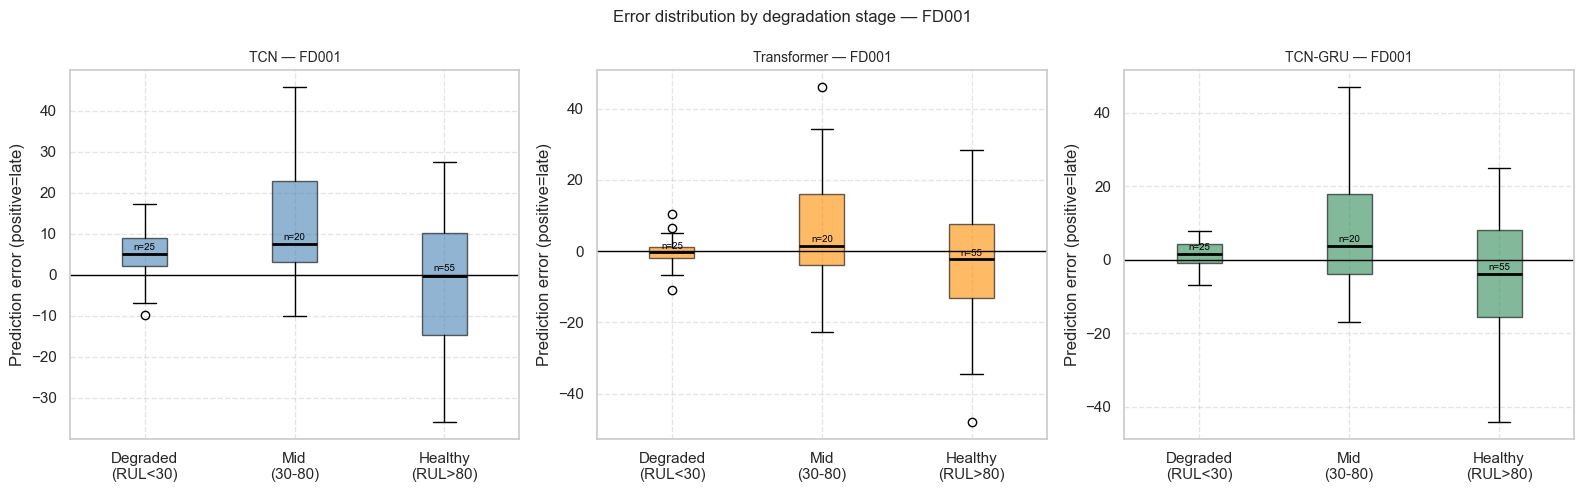

Saved -> figures_v12/v12_error_by_bucket_fd001.png


/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


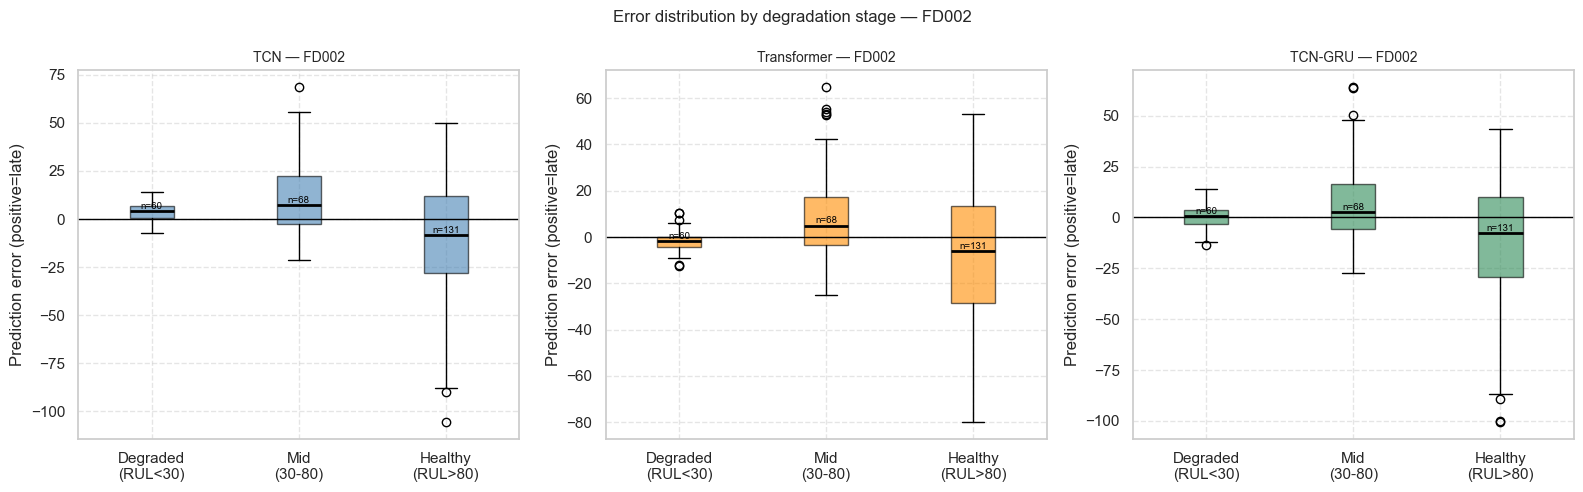

Saved -> figures_v12/v12_error_by_bucket_fd002.png


/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


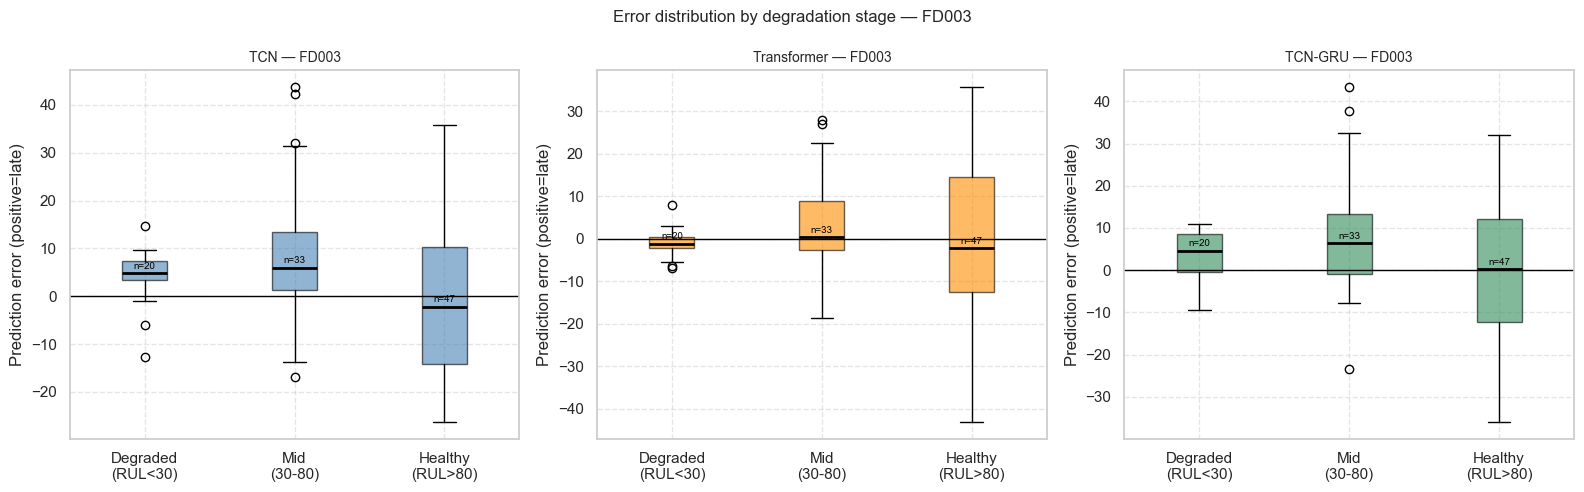

Saved -> figures_v12/v12_error_by_bucket_fd003.png


/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/4092746143.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


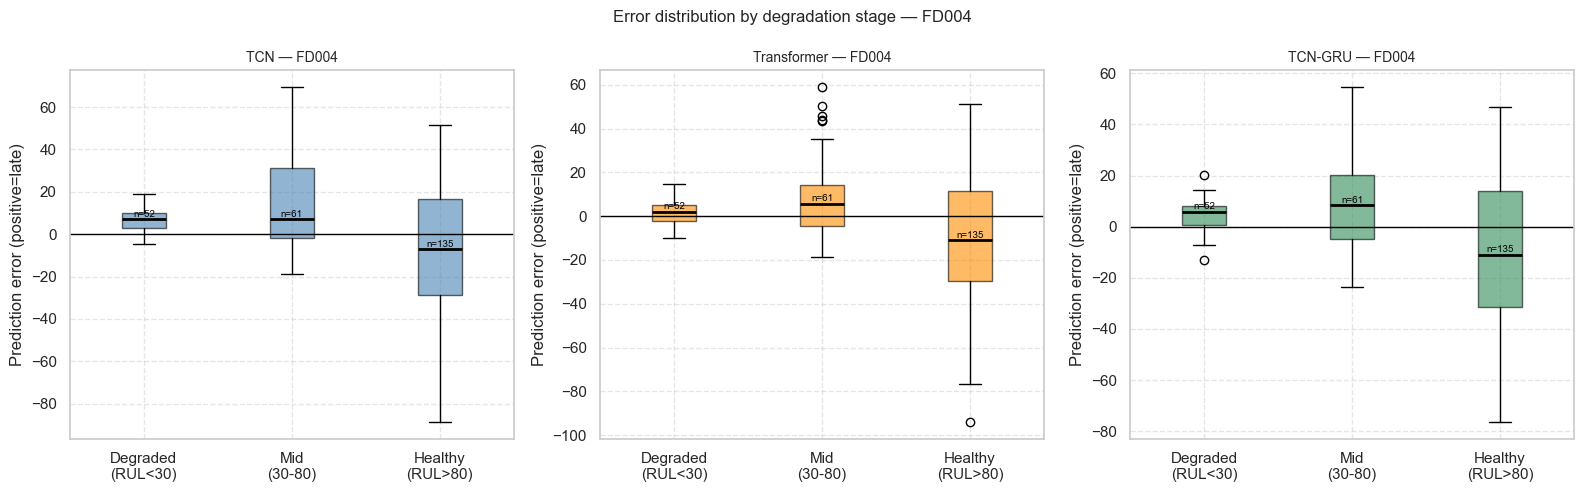

Saved -> figures_v12/v12_error_by_bucket_fd004.png


In [25]:
# Error distribution by degradation stage — all 4 subsets, all 3 base models

def bucket_errors(y_true, y_pred_raw):
    y_pred = np.clip(y_pred_raw, 0, None)
    errors = y_pred - y_true
    late  = y_true < 30
    mid   = (y_true >= 30) & (y_true < 80)
    early = y_true >= 80
    return {'Degraded\n(RUL<30)': errors[late],
            'Mid\n(30-80)':        errors[mid],
            'Healthy\n(RUL>80)':   errors[early]}

model_colors = {'TCN': 'steelblue', 'Transformer': 'darkorange', 'TCN-GRU': 'seagreen'}

for subset in SUBSETS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for col, (mname, model) in enumerate(model_specs):
        ax      = axes[col]
        raw_p   = run_inference(model, test_windows[subset], Device)
        buckets = bucket_errors(test_ruls[subset], raw_p)

        bp = ax.boxplot(
            [v for v in buckets.values()],
            labels=list(buckets.keys()),
            patch_artist=True, notch=False,
            medianprops=dict(color='black', linewidth=2),
        )
        for patch in bp['boxes']:
            patch.set_facecolor(model_colors[mname])
            patch.set_alpha(0.6)

        ax.axhline(0, color='black', lw=1)
        ax.set_title(f'{mname} — {subset}', fontsize=10)
        ax.set_ylabel('Prediction error (positive=late)')
        ax.grid(linestyle='--', alpha=0.5)

        for i, (k, v) in enumerate(buckets.items()):
            if len(v) > 0:
                ax.text(i + 1, np.median(v) + 1, f'n={len(v)}',
                        ha='center', fontsize=7, color='black')

    plt.suptitle(
        f'Error distribution by degradation stage — {subset}',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'v12_error_by_bucket_{subset.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR}/v12_error_by_bucket_{subset.lower()}.png')

## §13 · Visualization 5 — Transformer attention weight heatmap

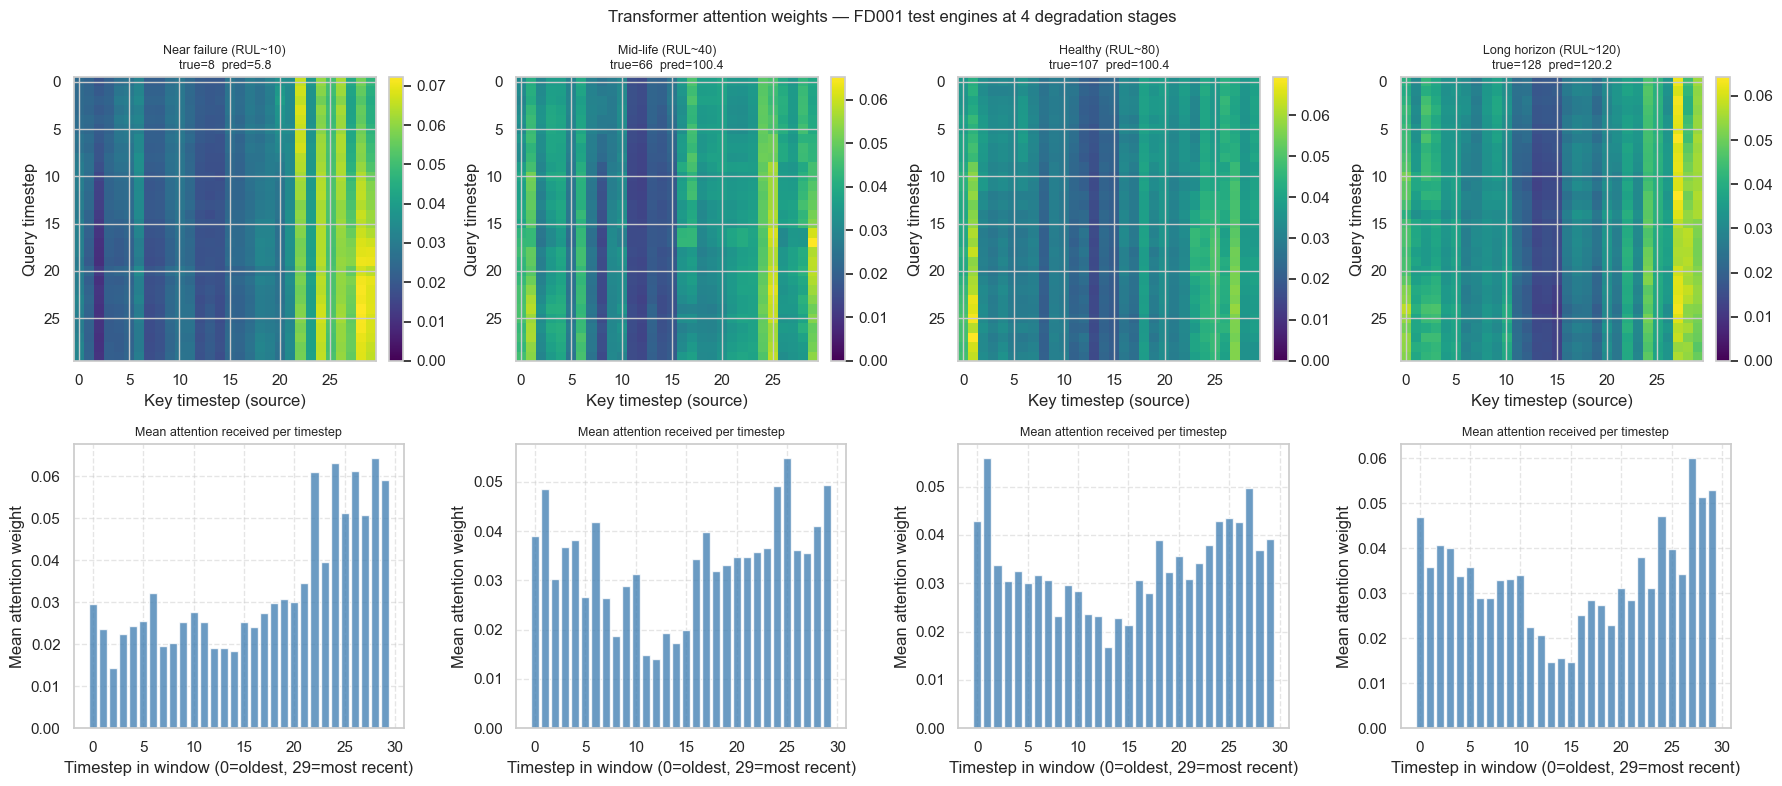

Saved -> figures_v12/v12_attention_heatmap.png


In [14]:
# For 4 FD001 test engines at different RUL stages, show which timesteps
# in the 30-cycle window the Transformer attends to most.
# Near-failure engines should attend to recent (late) timesteps more.
# Healthy engines may attend more uniformly or to early timesteps.

transformer_model.eval()
order_fd1  = np.argsort(test_ruls['FD001'])
attn_cases = [
    ('Near failure (RUL~10)',  order_fd1[3]),
    ('Mid-life (RUL~40)',      order_fd1[40]),
    ('Healthy (RUL~80)',       order_fd1[70]),
    ('Long horizon (RUL~120)', order_fd1[90]),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, (desc, eng_idx) in enumerate(attn_cases):
    # Get the last-window input for this engine
    window_X = test_windows['FD001'][eng_idx:eng_idx+1]  # (1, W, F)
    xb       = torch.from_numpy(window_X).to(Device)

    with torch.no_grad():
        enc, attn = transformer_model.encode_with_attn(xb)
        rul_pred  = transformer_model.rul_head(enc).squeeze().item()

    attn_map  = attn[0].cpu().numpy()  # (T, T)
    true_rul  = test_ruls['FD001'][eng_idx]

    # Top: attention heatmap (query=row, key=col)
    ax = axes[0, col]
    im = ax.imshow(attn_map, cmap='viridis', aspect='auto', vmin=0)
    ax.set_title(f'{desc}\ntrue={true_rul:.0f}  pred={rul_pred:.1f}', fontsize=9)
    ax.set_xlabel('Key timestep (source)')
    ax.set_ylabel('Query timestep')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Bottom: mean attention received per timestep (how much each step is attended to)
    ax2 = axes[1, col]
    mean_received = attn_map.mean(axis=0)  # average over all queries
    ax2.bar(range(W), mean_received, color='steelblue', alpha=0.8)
    ax2.set_xlabel('Timestep in window (0=oldest, 29=most recent)')
    ax2.set_ylabel('Mean attention weight')
    ax2.set_title('Mean attention received per timestep', fontsize=9)
    ax2.grid(linestyle='--', alpha=0.5)

plt.suptitle('Transformer attention weights — FD001 test engines at 4 degradation stages',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_attention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_attention_heatmap.png')

### For all the datasets now

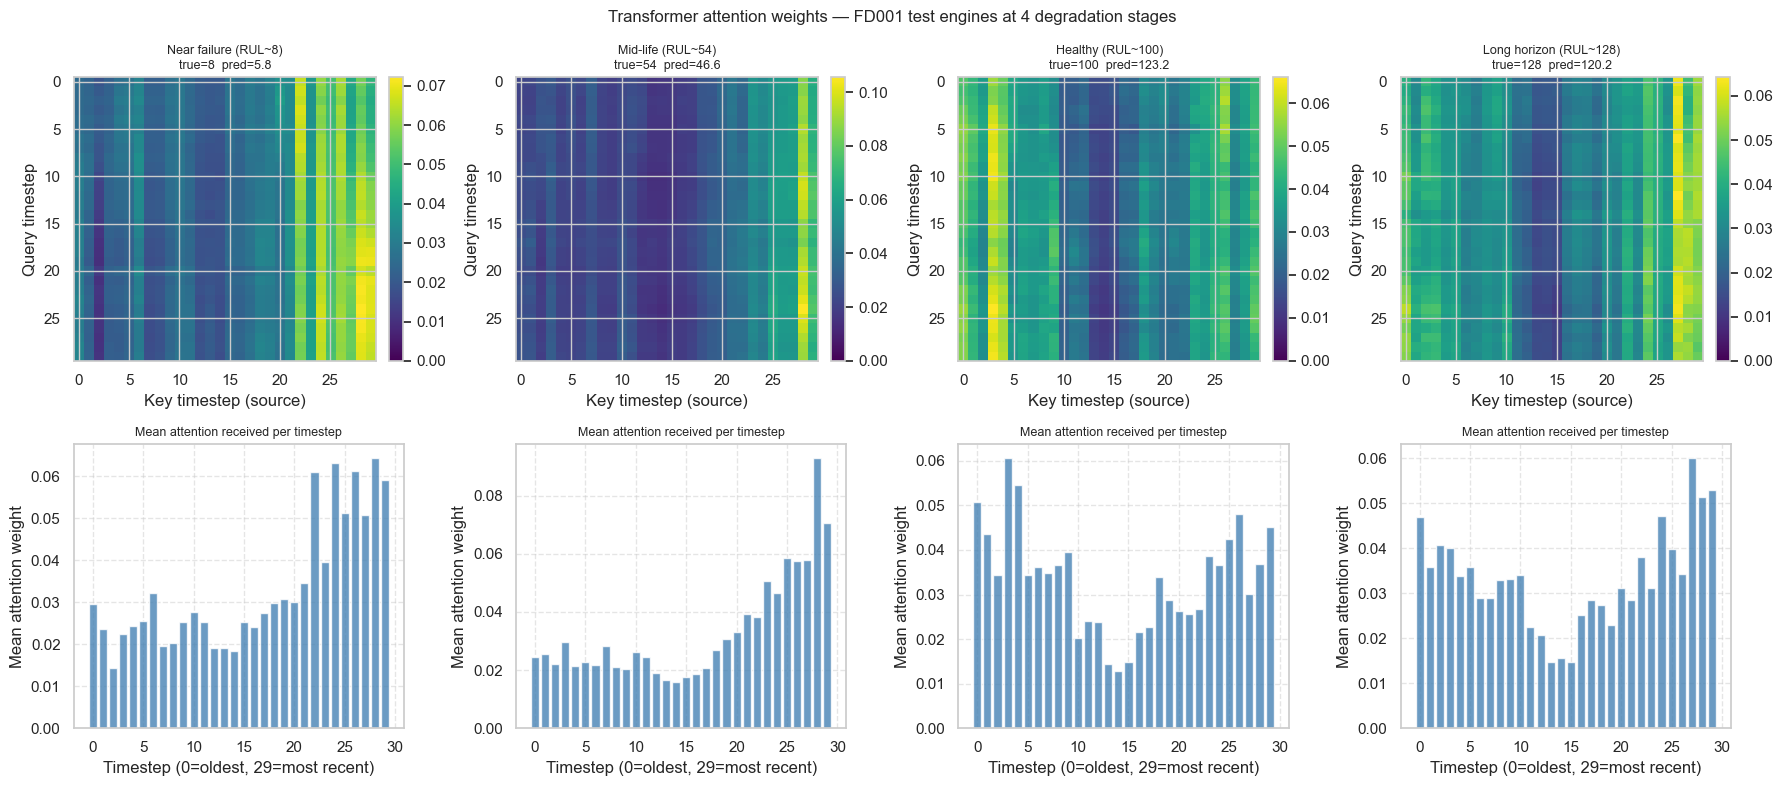

Saved -> figures_v12/v12_attention_heatmap_fd001.png


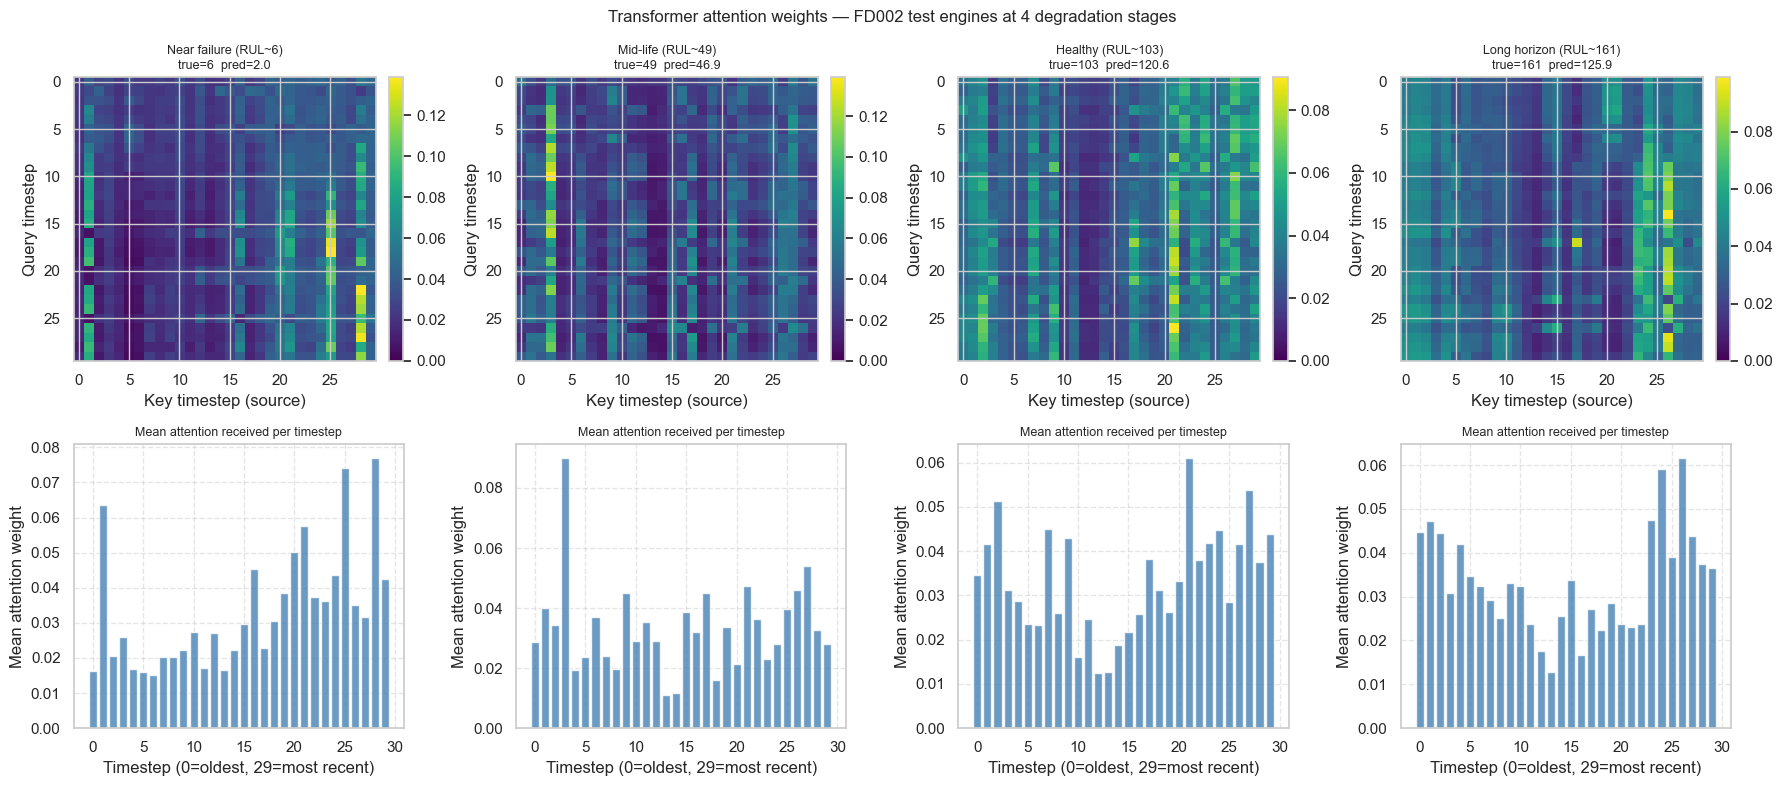

Saved -> figures_v12/v12_attention_heatmap_fd002.png


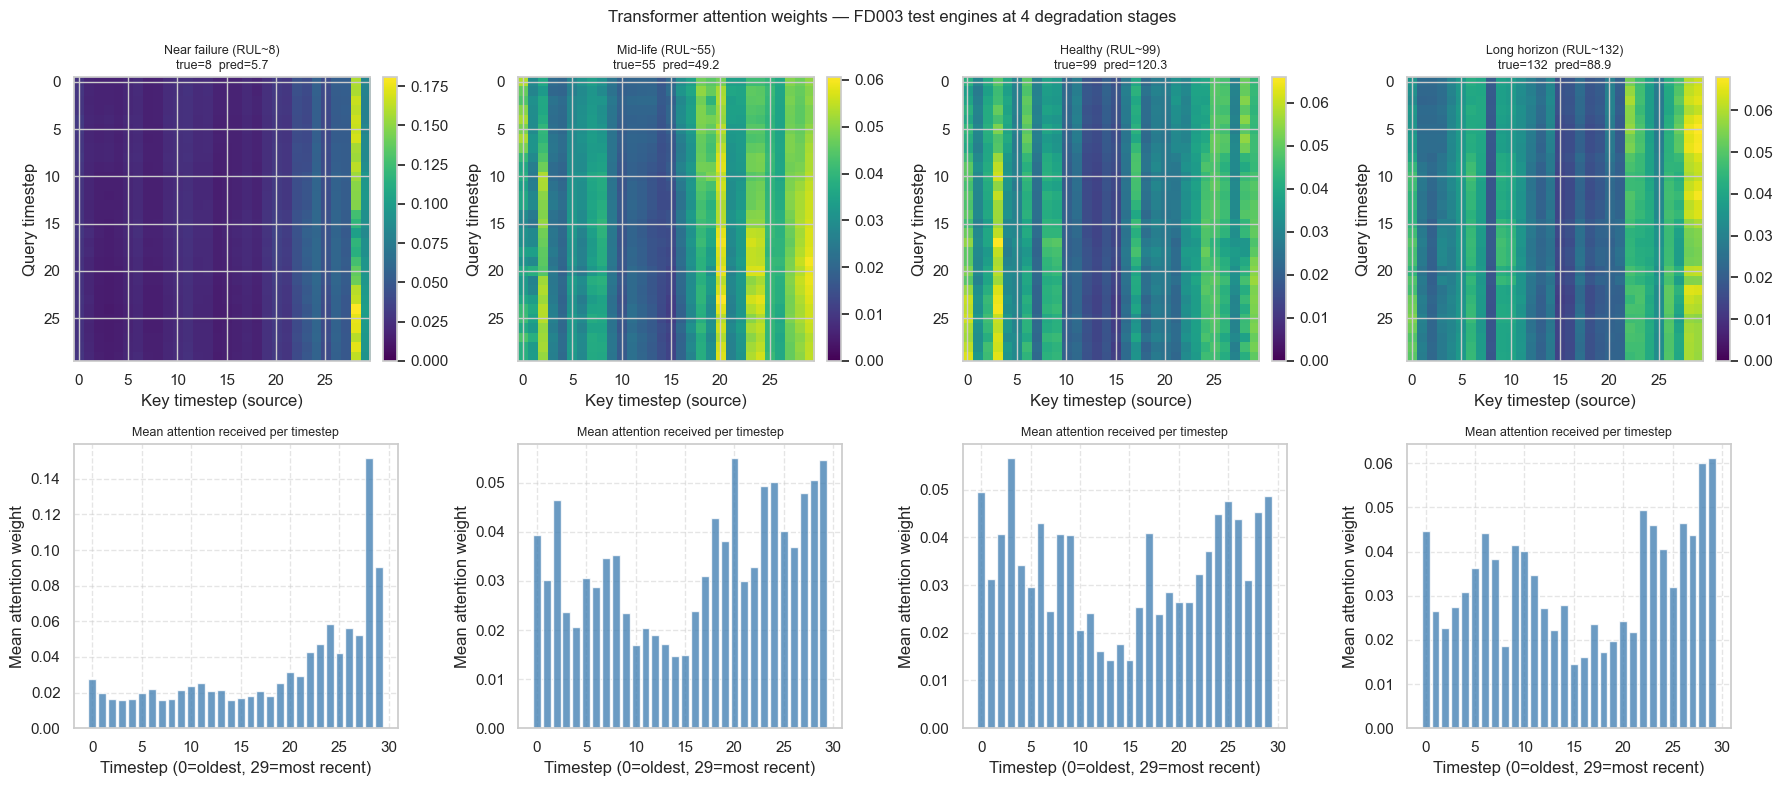

Saved -> figures_v12/v12_attention_heatmap_fd003.png


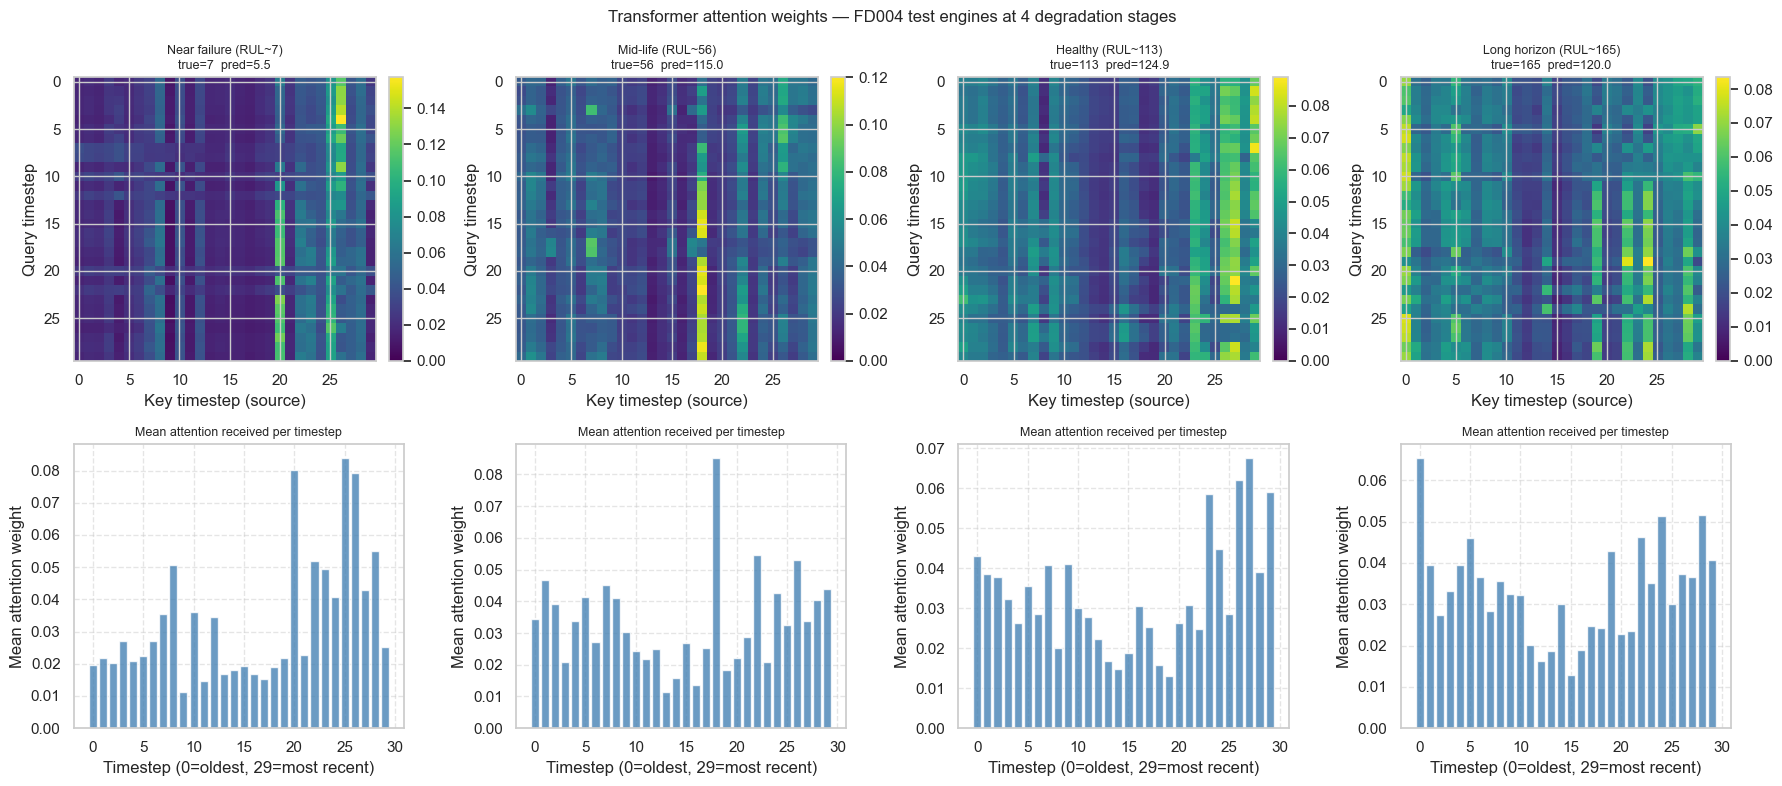

Saved -> figures_v12/v12_attention_heatmap_fd004.png


In [23]:
# Attention heatmap for all 4 subsets — 2 rows × 4 cols per subset figure
transformer_model.eval()

for subset in SUBSETS:
    yt          = test_ruls[subset]
    order       = np.argsort(yt)
    n_engines   = len(yt)

    # Pick 4 engines spread across the RUL distribution, clamped to valid indices
    idx_near    = order[min(3,             n_engines - 1)]
    idx_mid     = order[min(n_engines // 3,      n_engines - 1)]
    idx_healthy = order[min(2 * n_engines // 3,  n_engines - 1)]
    idx_long    = order[min(int(0.9 * n_engines), n_engines - 1)]

    attn_cases = [
        (f'Near failure (RUL~{yt[idx_near]:.0f})',   idx_near),
        (f'Mid-life (RUL~{yt[idx_mid]:.0f})',         idx_mid),
        (f'Healthy (RUL~{yt[idx_healthy]:.0f})',      idx_healthy),
        (f'Long horizon (RUL~{yt[idx_long]:.0f})',    idx_long),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    for col, (desc, eng_idx) in enumerate(attn_cases):
        window_X = test_windows[subset][eng_idx:eng_idx + 1]   # (1, W, F)
        xb       = torch.from_numpy(window_X).to(Device)

        with torch.no_grad():
            enc, attn = transformer_model.encode_with_attn(xb)
            rul_pred  = transformer_model.rul_head(enc).squeeze().item()

        attn_map = attn[0].cpu().numpy()   # (T, T)
        true_rul = yt[eng_idx]

        # Top: attention heatmap
        ax = axes[0, col]
        im = ax.imshow(attn_map, cmap='viridis', aspect='auto', vmin=0)
        ax.set_title(f'{desc}\ntrue={true_rul:.0f}  pred={rul_pred:.1f}', fontsize=9)
        ax.set_xlabel('Key timestep (source)')
        ax.set_ylabel('Query timestep')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Bottom: mean attention received per timestep
        ax2 = axes[1, col]
        mean_received = attn_map.mean(axis=0)
        ax2.bar(range(W), mean_received, color='steelblue', alpha=0.8)
        ax2.set_xlabel('Timestep (0=oldest, 29=most recent)')
        ax2.set_ylabel('Mean attention weight')
        ax2.set_title('Mean attention received per timestep', fontsize=9)
        ax2.grid(linestyle='--', alpha=0.5)

    plt.suptitle(
        f'Transformer attention weights — {subset} test engines at 4 degradation stages',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'v12_attention_heatmap_{subset.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR}/v12_attention_heatmap_{subset.lower()}.png')

## §14 · t-SNE (unchanged from v11, now with clean normalization)

t-SNE for TCN (enc shape=(2000, 32))...
t-SNE for Transformer (enc shape=(2000, 64))...
t-SNE for TCN-GRU (enc shape=(2000, 160))...


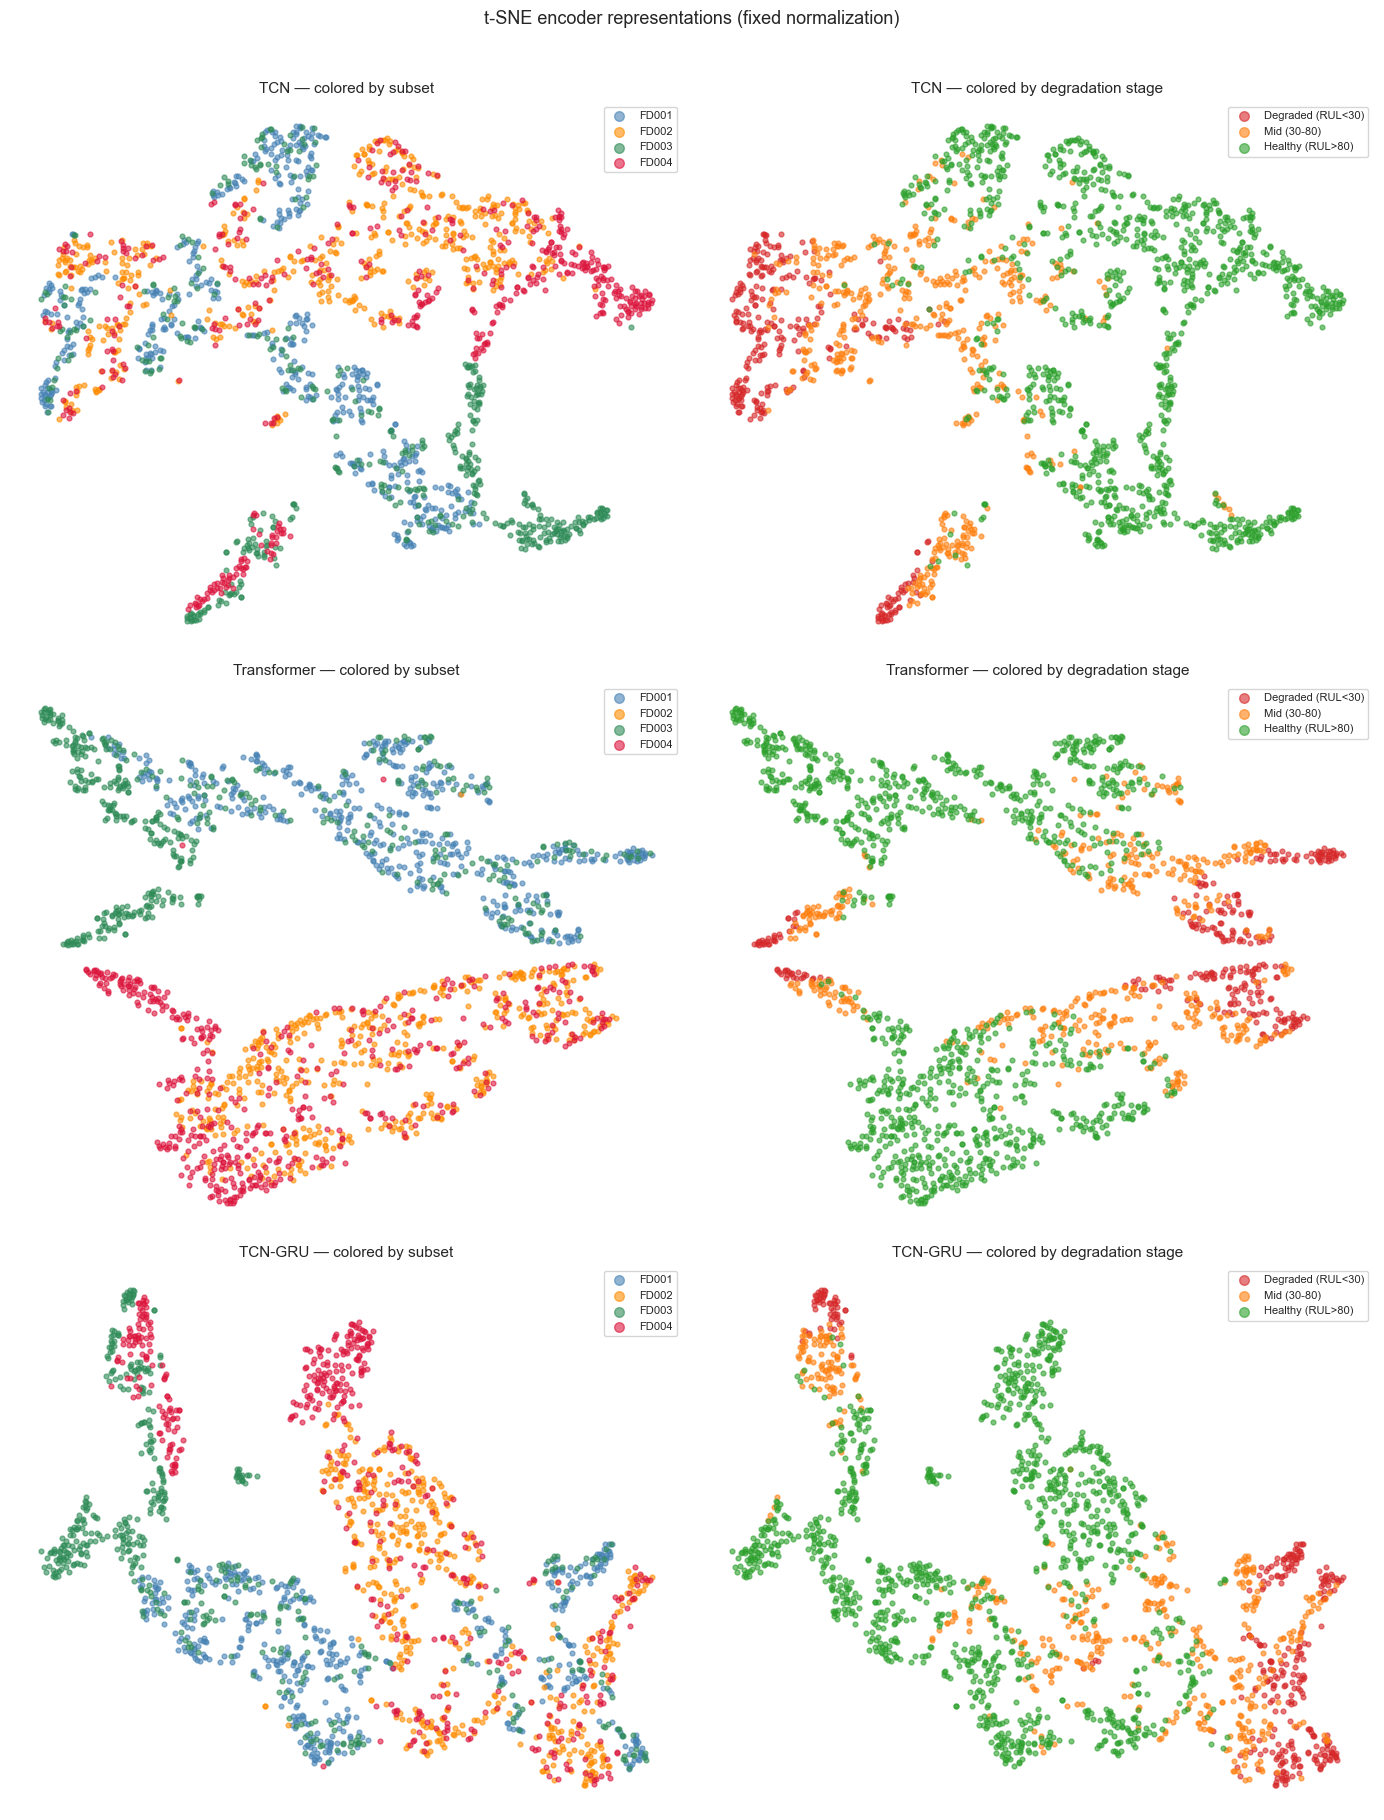

Saved -> figures_v12/v12_tsne.png


In [15]:
@torch.no_grad()
def extract_encodings(model, datasets, device, n_per_subset=500, seed=0):
    model.eval()
    rng = np.random.default_rng(seed)
    all_enc, all_sub, all_rul = [], [], []
    for sub_idx in range(len(SUBSETS)):
        ds   = datasets[sub_idx]
        idxs = rng.choice(len(ds), size=min(n_per_subset, len(ds)), replace=False)
        Xs   = torch.from_numpy(ds.X[idxs]).to(device)
        enc  = model.encode(Xs).cpu().numpy()
        all_enc.append(enc)
        all_sub.append(np.full(len(idxs), sub_idx))
        all_rul.append(ds.y[idxs])
    return np.concatenate(all_enc), np.concatenate(all_sub), np.concatenate(all_rul)


def rul_to_bucket(ruls):
    b = np.zeros(len(ruls), dtype=int)
    b[ruls >= 30] = 1; b[ruls >= 80] = 2
    return b


SUBSET_COLORS = ['steelblue','darkorange','seagreen','crimson']
BUCKET_COLORS = ['#d62728','#ff7f0e','#2ca02c']
BUCKET_NAMES  = ['Degraded (RUL<30)','Mid (30-80)','Healthy (RUL>80)']

fig, axes = plt.subplots(3, 2, figsize=(14, 18))

for row, (name, model) in enumerate(model_specs):
    enc, sub_labels, rul_vals = extract_encodings(
        model, train_datasets, Device, n_per_subset=500, seed=SEED)
    print(f't-SNE for {name} (enc shape={enc.shape})...')
    tsne   = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
    coords = tsne.fit_transform(enc)

    ax = axes[row, 0]
    for i, s in enumerate(SUBSETS):
        mask = sub_labels == i
        ax.scatter(coords[mask,0], coords[mask,1], c=SUBSET_COLORS[i],
                   s=12, alpha=0.6, label=s)
    ax.set_title(f'{name} — colored by subset', fontsize=11)
    ax.legend(fontsize=8, markerscale=2); ax.axis('off')

    ax = axes[row, 1]
    buckets = rul_to_bucket(rul_vals)
    for b, (c, lbl) in enumerate(zip(BUCKET_COLORS, BUCKET_NAMES)):
        ax.scatter(coords[buckets==b,0], coords[buckets==b,1],
                   c=c, s=12, alpha=0.6, label=lbl)
    ax.set_title(f'{name} — colored by degradation stage', fontsize=11)
    ax.legend(fontsize=8, markerscale=2); ax.axis('off')

plt.suptitle('t-SNE encoder representations (fixed normalization)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_tsne.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_tsne.png')

## §15 · GRL models — now with clean normalization

With the settings-clamping fix in §2, FD002/FD004 test inputs no longer contain
NaN/Inf values. The GRL comparison is now meaningful.


In [16]:
class GRLWrapper(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder     = encoder
        self.grl         = GradientReversalLayer()
        self.domain_head = nn.Sequential(
            nn.Linear(encoder.enc_dim, 32), nn.ReLU(), nn.Linear(32, 1)
        )

    def predict_rul(self, x): return self.encoder(x)

    def forward(self, x_src, x_tgt):
        h_src = self.encoder.encode(x_src)
        h_tgt = self.encoder.encode(x_tgt)
        rul_pred   = self.encoder.rul_head(h_src).squeeze(-1)
        state_pred = self.encoder.state_head(h_src).squeeze(-1)
        h_all      = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all)).squeeze(-1)
        return rul_pred, state_pred, dom_logits


class DANNTracker:
    def __init__(self, n_epochs, title='', plot_freq=1):
        self.n_epochs=n_epochs; self.plot_freq=plot_freq; self.title=title
        self.epoch=0
        self.total_loss=[]; self.rul_loss=[]; self.dom_loss=[]; self.val_rmse=[]; self.lam_hist=[]
        self._stopped_at=None; self.t0=time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_rul, self.ax_dom) = axes
        self.c_tot,=self.ax_tot.plot([],[],color='steelblue')
        self.c_val,=self.ax_val.plot([],[],color='darkorange')
        self.c_rul,=self.ax_rul.plot([],[],color='seagreen')
        self.c_dom,=self.ax_dom.plot([],[],color='mediumpurple')
        self.ax_dom2=self.ax_dom.twinx()
        self.c_lam,=self.ax_dom2.plot([],[],color='gray',linestyle='--',alpha=0.7)
        for ax,t,yl in [(self.ax_tot,'Total loss','Loss'),(self.ax_val,'Val RMSE','RMSE'),
                        (self.ax_rul,'RUL loss','Loss'),(self.ax_dom,'Domain BCE + lambda','BCE')]:
            ax.set_title(t); ax.set_xlabel('Epoch'); ax.set_ylabel(yl)
            ax.set_xlim(0,n_epochs+1); ax.grid(linestyle='--',alpha=0.6)
        self.ax_dom2.set_ylabel('lambda'); plt.tight_layout()
    def update_epoch(self, tot, rul, dom, vr, lam):
        self.total_loss.append(tot); self.rul_loss.append(rul)
        self.dom_loss.append(dom); self.val_rmse.append(vr); self.lam_hist.append(lam)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs: self._redraw()
    def mark_early_stop(self, ep): self._stopped_at = ep
    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c,d,ax in [(self.c_tot,self.total_loss,self.ax_tot),(self.c_val,self.val_rmse,self.ax_val),
                       (self.c_rul,self.rul_loss,self.ax_rul),(self.c_dom,self.dom_loss,self.ax_dom)]:
            c.set_data(xs,d); ax.relim(); ax.autoscale_view()
        self.c_lam.set_data(xs,self.lam_hist); self.ax_dom2.relim(); self.ax_dom2.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot,self.ax_val,self.ax_rul,self.ax_dom):
                ax.axvline(self._stopped_at,color='crimson',linestyle=':',lw=1.5)
        elapsed=time.time()-self.t0; eta=(elapsed/max(self.epoch,1))*(self.n_epochs-self.epoch)
        suffix='  [ES]' if self._stopped_at else ''
        self.fig.suptitle(
            f'{self.title}  Ep {self.epoch}/{self.n_epochs}  '
            f'val={self.val_rmse[-1]:.2f}  lam={self.lam_hist[-1]:.3f}  '
            f'{elapsed:.0f}s  ETA {eta:.0f}s{suffix}', fontsize=10)
        clear_output(wait=True); display(self.fig)
    def close(self): plt.close(self.fig)


def train_grl(
    grl_model, src_loader, tgt_loader, val_loader,
    warmup_epochs=10, total_epochs=60,
    lr=5e-4, weight_decay=1e-4, grad_clip=1.0, patience=15,
    late_weight=1.3, state_weight=0.3, lambda_max=1.0,
    device=Device, ckpt_path=None, tracker_title='',
):
    grl_model  = grl_model.to(device)
    opt        = optim.Adam(grl_model.parameters(), lr=lr, weight_decay=weight_decay)
    sched      = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=total_epochs)
    dom_crit   = nn.BCEWithLogitsLoss()
    tracker    = DANNTracker(total_epochs, title=tracker_title)
    history    = []
    phase2_eps = total_epochs - warmup_epochs
    best_val=float('inf'); best_epoch=0; no_improve=0; best_state=None

    pbar = tqdm(range(1, total_epochs+1), desc=tracker_title, unit='epoch')
    for epoch in pbar:
        lam = 0.0 if epoch <= warmup_epochs else ganin_lambda(
            epoch - warmup_epochs, phase2_eps, high=lambda_max)
        grl_model.grl.lam = lam
        grl_model.train()
        ep_tot, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0
        tgt_iter = itertools.cycle(tgt_loader)
        for x_src, y_src, pos_src in src_loader:
            x_tgt   = next(tgt_iter)[0]
            x_src, y_src = x_src.to(device), y_src.to(device)
            pos_src = pos_src.to(device); x_tgt = x_tgt.to(device)
            rul_pred, state_pred, dom_logits = grl_model(x_src, x_tgt)
            B_src = x_src.size(0); B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])
            l_rul   = asymmetric_mse(rul_pred, y_src, late_weight)
            l_state = F.mse_loss(state_pred, pos_src)
            l_dom   = dom_crit(dom_logits, dom_labels)
            loss    = l_rul + state_weight * l_state + lam * l_dom
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(grl_model.parameters(), grad_clip)
            opt.step()
            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_n  += B_src
        sched.step()
        _, val_rmse = evaluate_loader(grl_model.encoder, val_loader, device)
        history.append(dict(epoch=epoch, total_loss=ep_tot/ep_n, rul_loss=ep_rul/ep_n,
                            dom_loss=ep_dom/ep_n, val_rmse=val_rmse, lam=lam))
        tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, val_rmse, lam)
        pbar.set_postfix({'val': f'{val_rmse:.2f}', 'lam': f'{lam:.3f}',
                          'ph': 'P1' if epoch <= warmup_epochs else 'P2',
                          'no_imp': no_improve})
        if val_rmse < best_val:
            best_val=val_rmse; best_epoch=epoch; no_improve=0
            best_state = copy.deepcopy(grl_model.state_dict())
            if ckpt_path:
                torch.save({'model': best_state, 'epoch': epoch,
                            'val_rmse': val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                tracker.mark_early_stop(epoch); tracker._redraw(); break
    tracker.close()
    print(f'Best val RMSE = {best_val:.3f} at epoch {best_epoch}')
    if best_state: grl_model.load_state_dict(best_state)
    return grl_model, pd.DataFrame(history)

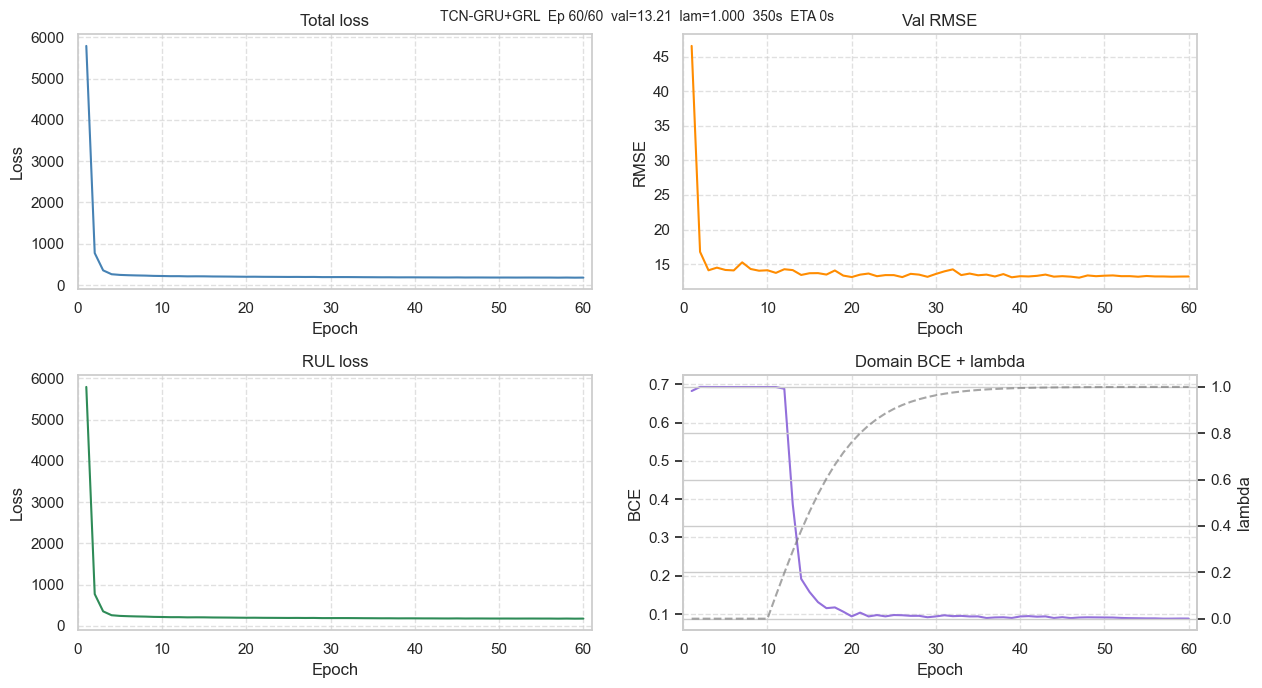

Best val RMSE = 13.039 at epoch 47

[TCN-GRU+GRL]
[FD001]
  RMSE=15.390  Score=437  MAE=10.777  Bias=-0.289
[FD002]
  RMSE=54.717  Score=2640921  MAE=42.296  Bias=-27.143
[FD003]
  RMSE=14.961  Score=416  MAE=11.128  Bias=+1.340
[FD004]
  RMSE=53.150  Score=1618266  MAE=40.403  Bias=-25.810


In [17]:
src_train  = ConcatDataset([train_datasets[SUBSETS.index(s)] for s in SRC_SUBSETS])
tgt_train  = ConcatDataset([train_datasets[SUBSETS.index(s)] for s in TGT_SUBSETS])
src_val    = ConcatDataset([val_datasets[SUBSETS.index(s)]   for s in SRC_SUBSETS])

src_loader_grl = DataLoader(src_train, batch_size=256, shuffle=True,  num_workers=0)
tgt_loader_grl = DataLoader(tgt_train, batch_size=256, shuffle=True,  num_workers=0)
src_val_loader = DataLoader(src_val,   batch_size=256, shuffle=False, num_workers=0)

grl_metrics   = {}
grl_histories = {}

grl_specs = [
    ('TCN+GRL',         TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer+GRL', LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                               dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU+GRL',     TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32,
                                      gru_hidden=64, dropout=0.2)),
]

for name, encoder in grl_specs:
    print(f'\n{"="*55}\nTraining {name}\n{"="*55}')
    set_seed(SEED)
    grl_model = GRLWrapper(encoder)
    safe_name = name.lower().replace('+','_').replace('-','_')
    grl_model, grl_hist = train_grl(
        grl_model,
        src_loader=src_loader_grl, tgt_loader=tgt_loader_grl, val_loader=src_val_loader,
        warmup_epochs=10, total_epochs=60,
        lr=5e-4, weight_decay=1e-4, grad_clip=1.0, patience=15,
        late_weight=1.3, state_weight=0.3, lambda_max=1.0,
        device=Device, ckpt_path=CKPT_DIR/f'grl_{safe_name}.pt',
        tracker_title=name,
    )
    grl_metrics[name]   = eval_all_subsets(grl_model, Device, name, is_dann=True)
    grl_histories[name] = grl_hist
    grl_hist.to_csv(CKPT_DIR/f'grl_{safe_name}_hist.csv', index=False)

## §16 · Visualization 6 — GRL lambda ramp vs domain loss vs val RMSE

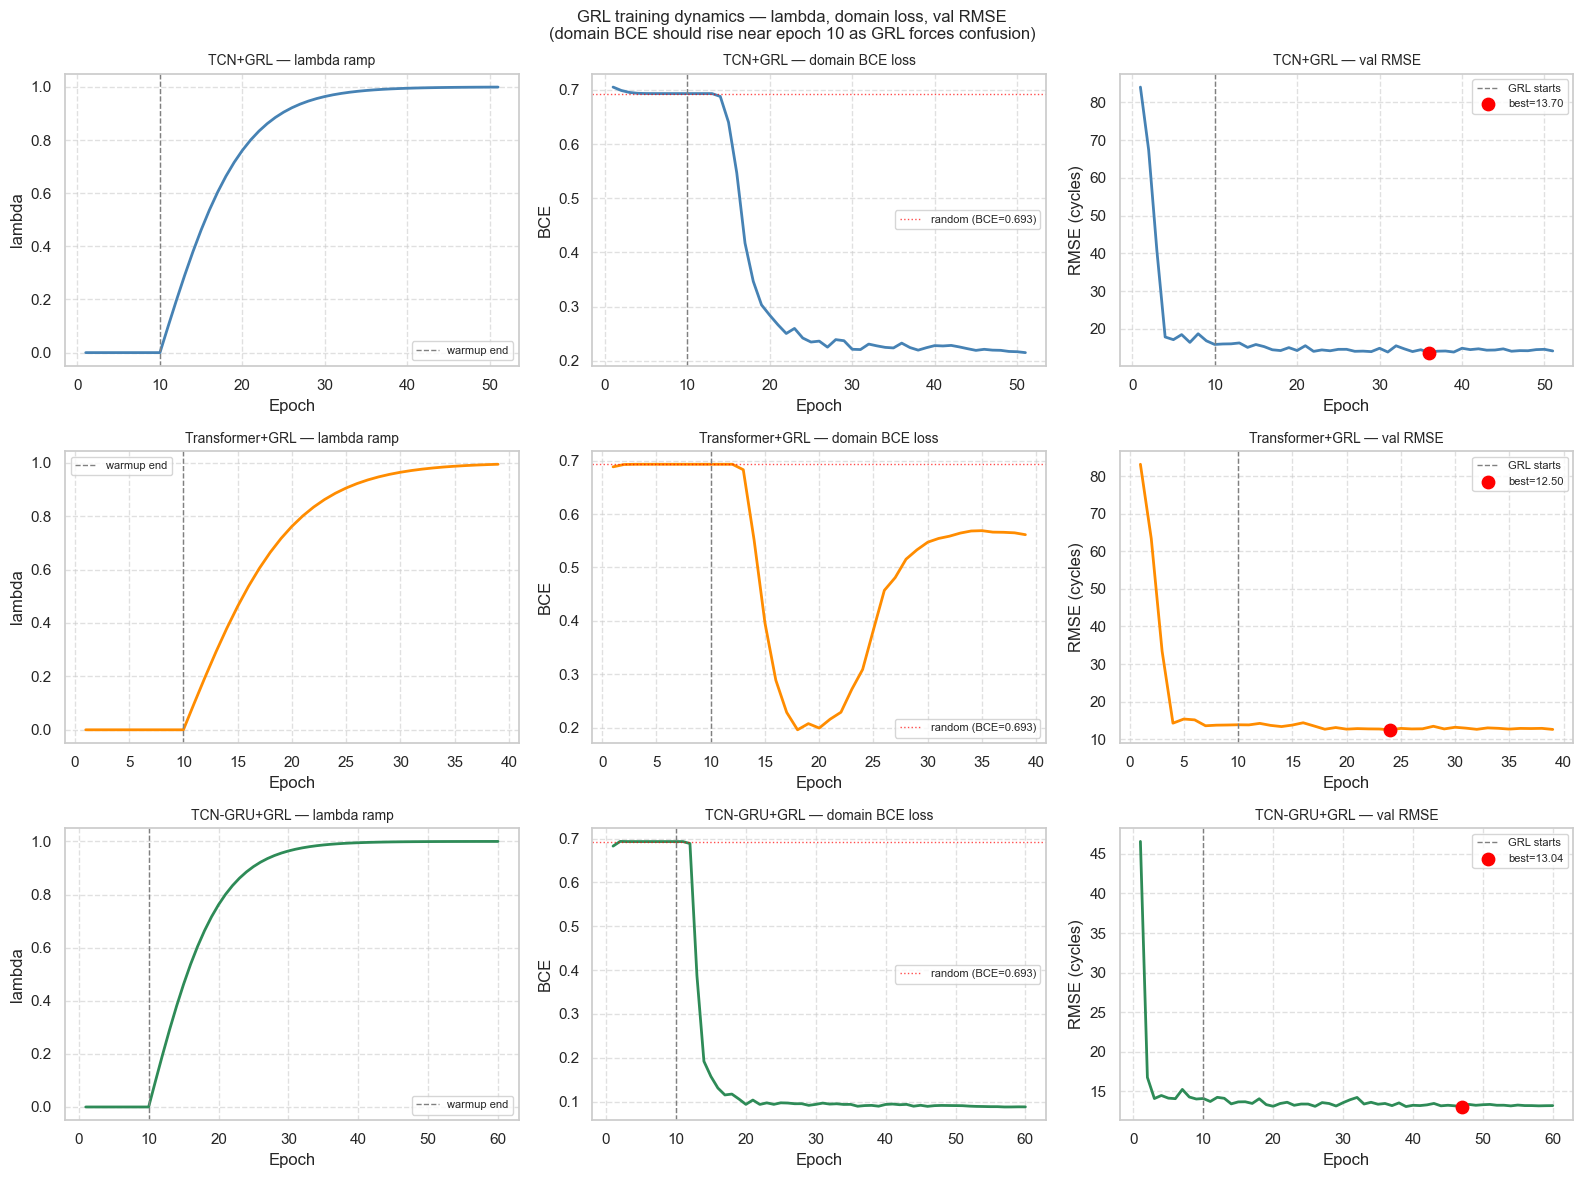

Saved -> figures_v12/v12_grl_dynamics.png


In [18]:
# 3-panel figure per GRL model: shows the interplay between
# lambda ramp (starts at epoch 10), domain loss response, and val RMSE.
# Good GRL training: domain loss should INCREASE when lambda ramps
# (classifier is being confused), then stabilize. Val RMSE should stay flat or improve.

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
grl_colors = {'TCN+GRL': 'steelblue', 'Transformer+GRL': 'darkorange', 'TCN-GRU+GRL': 'seagreen'}

for row, (gname, hist) in enumerate(grl_histories.items()):
    color = grl_colors[gname]
    eps   = hist['epoch'].values

    # Col 0: lambda ramp
    ax = axes[row, 0]
    ax.plot(eps, hist['lam'], color=color, lw=2)
    ax.axvline(10, color='gray', linestyle='--', lw=1, label='warmup end')
    ax.set_title(f'{gname} — lambda ramp', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('lambda')
    ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.6)

    # Col 1: domain loss
    ax = axes[row, 1]
    ax.plot(eps, hist['dom_loss'], color=color, lw=2)
    ax.axvline(10, color='gray', linestyle='--', lw=1)
    ax.set_title(f'{gname} — domain BCE loss', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('BCE')
    ax.grid(linestyle='--', alpha=0.6)
    # Annotate: BCE ~ log(2) ≈ 0.693 = random classifier
    ax.axhline(0.693, color='red', linestyle=':', lw=1, alpha=0.7,
               label='random (BCE=0.693)')
    ax.legend(fontsize=8)

    # Col 2: val RMSE with phase boundary
    ax = axes[row, 2]
    ax.plot(eps, hist['val_rmse'], color=color, lw=2)
    ax.axvline(10, color='gray', linestyle='--', lw=1, label='GRL starts')
    best_ep = hist.loc[hist['val_rmse'].idxmin(), 'epoch']
    best_vr = hist['val_rmse'].min()
    ax.scatter([best_ep], [best_vr], color='red', s=80, zorder=5,
               label=f'best={best_vr:.2f}')
    ax.set_title(f'{gname} — val RMSE', fontsize=10)
    ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (cycles)')
    ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.6)

plt.suptitle('GRL training dynamics — lambda, domain loss, val RMSE\n'
             '(domain BCE should rise near epoch 10 as GRL forces confusion)',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR/'v12_grl_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {FIG_DIR}/v12_grl_dynamics.png')

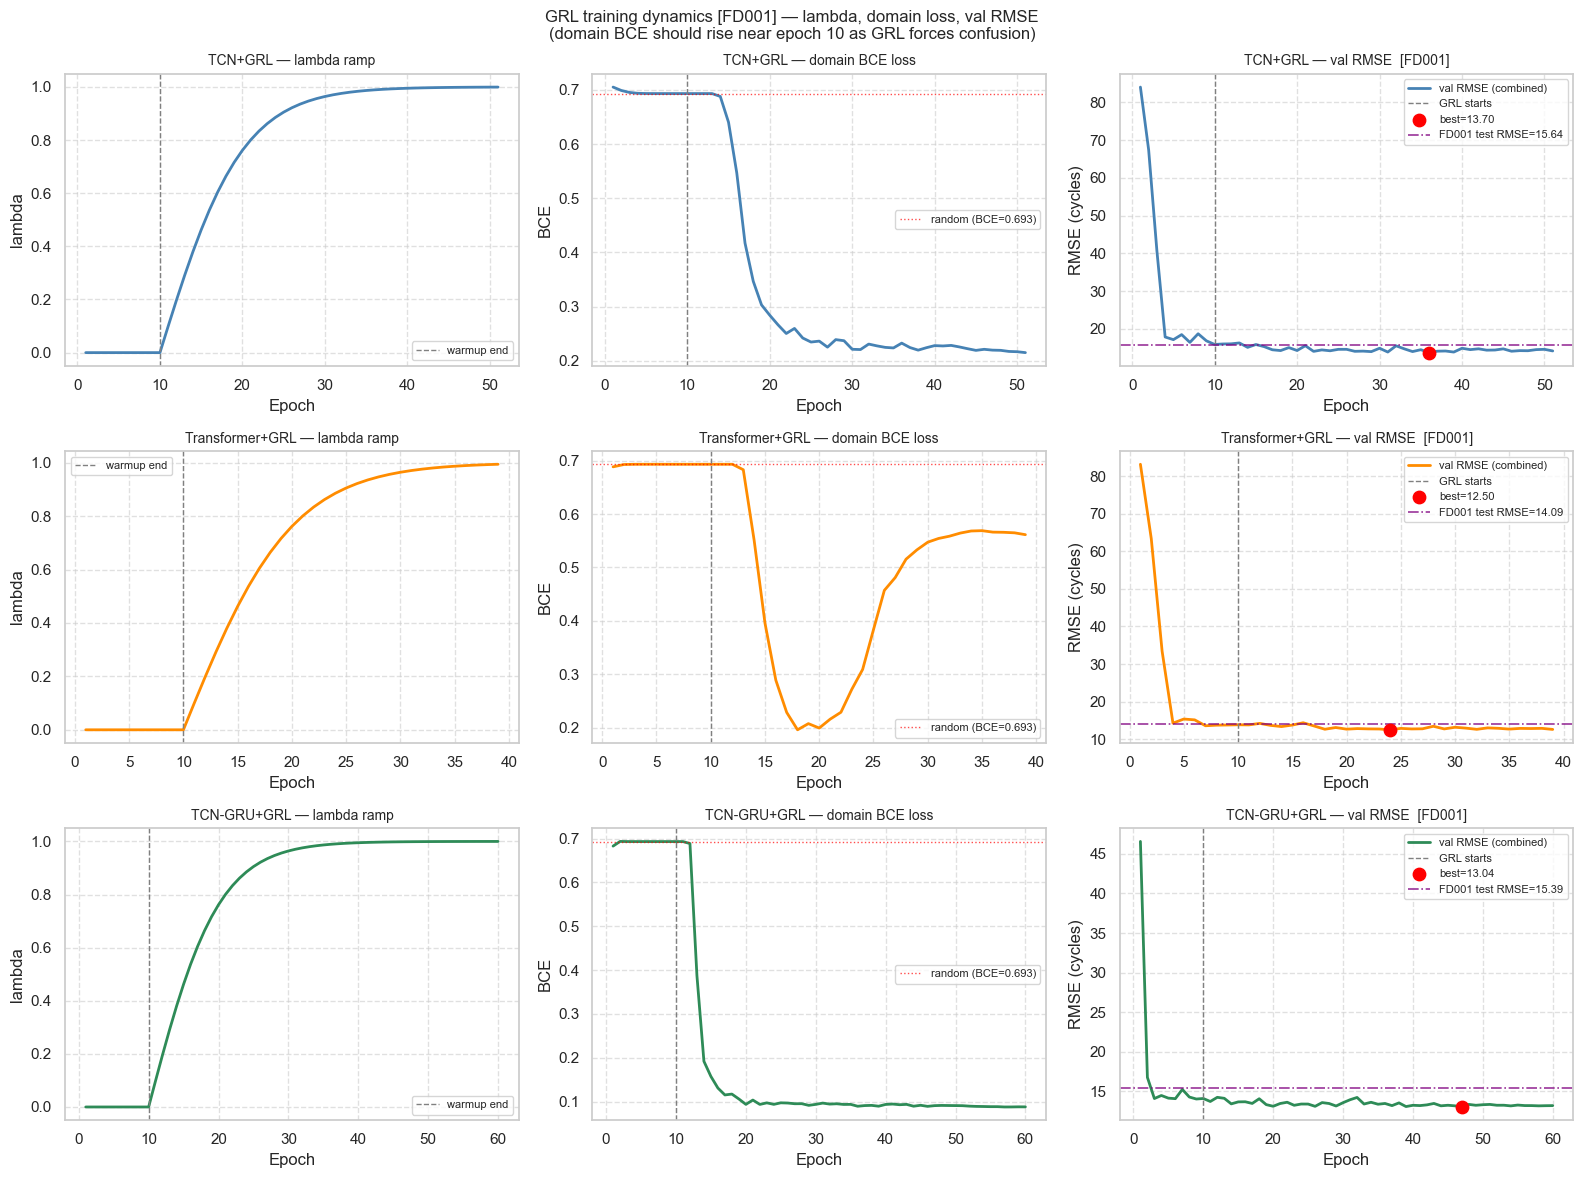

Saved -> figures_v12/v12_grl_dynamics_fd001.png


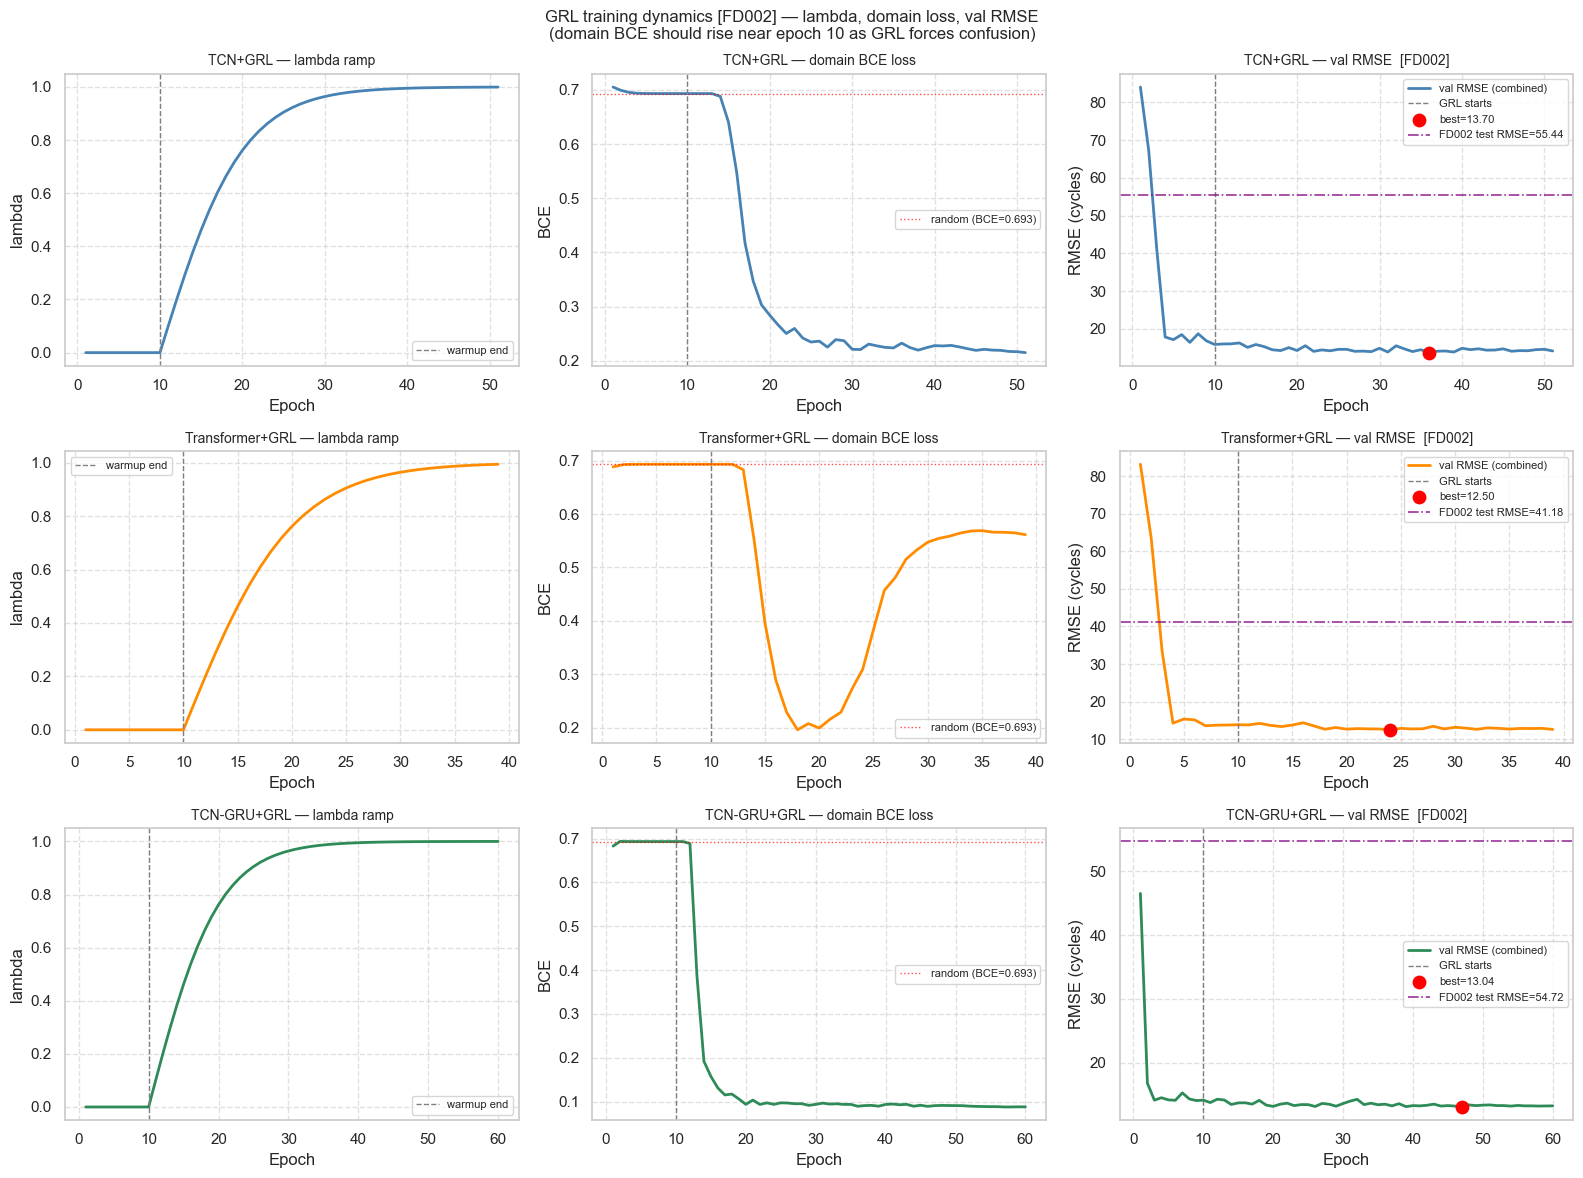

Saved -> figures_v12/v12_grl_dynamics_fd002.png


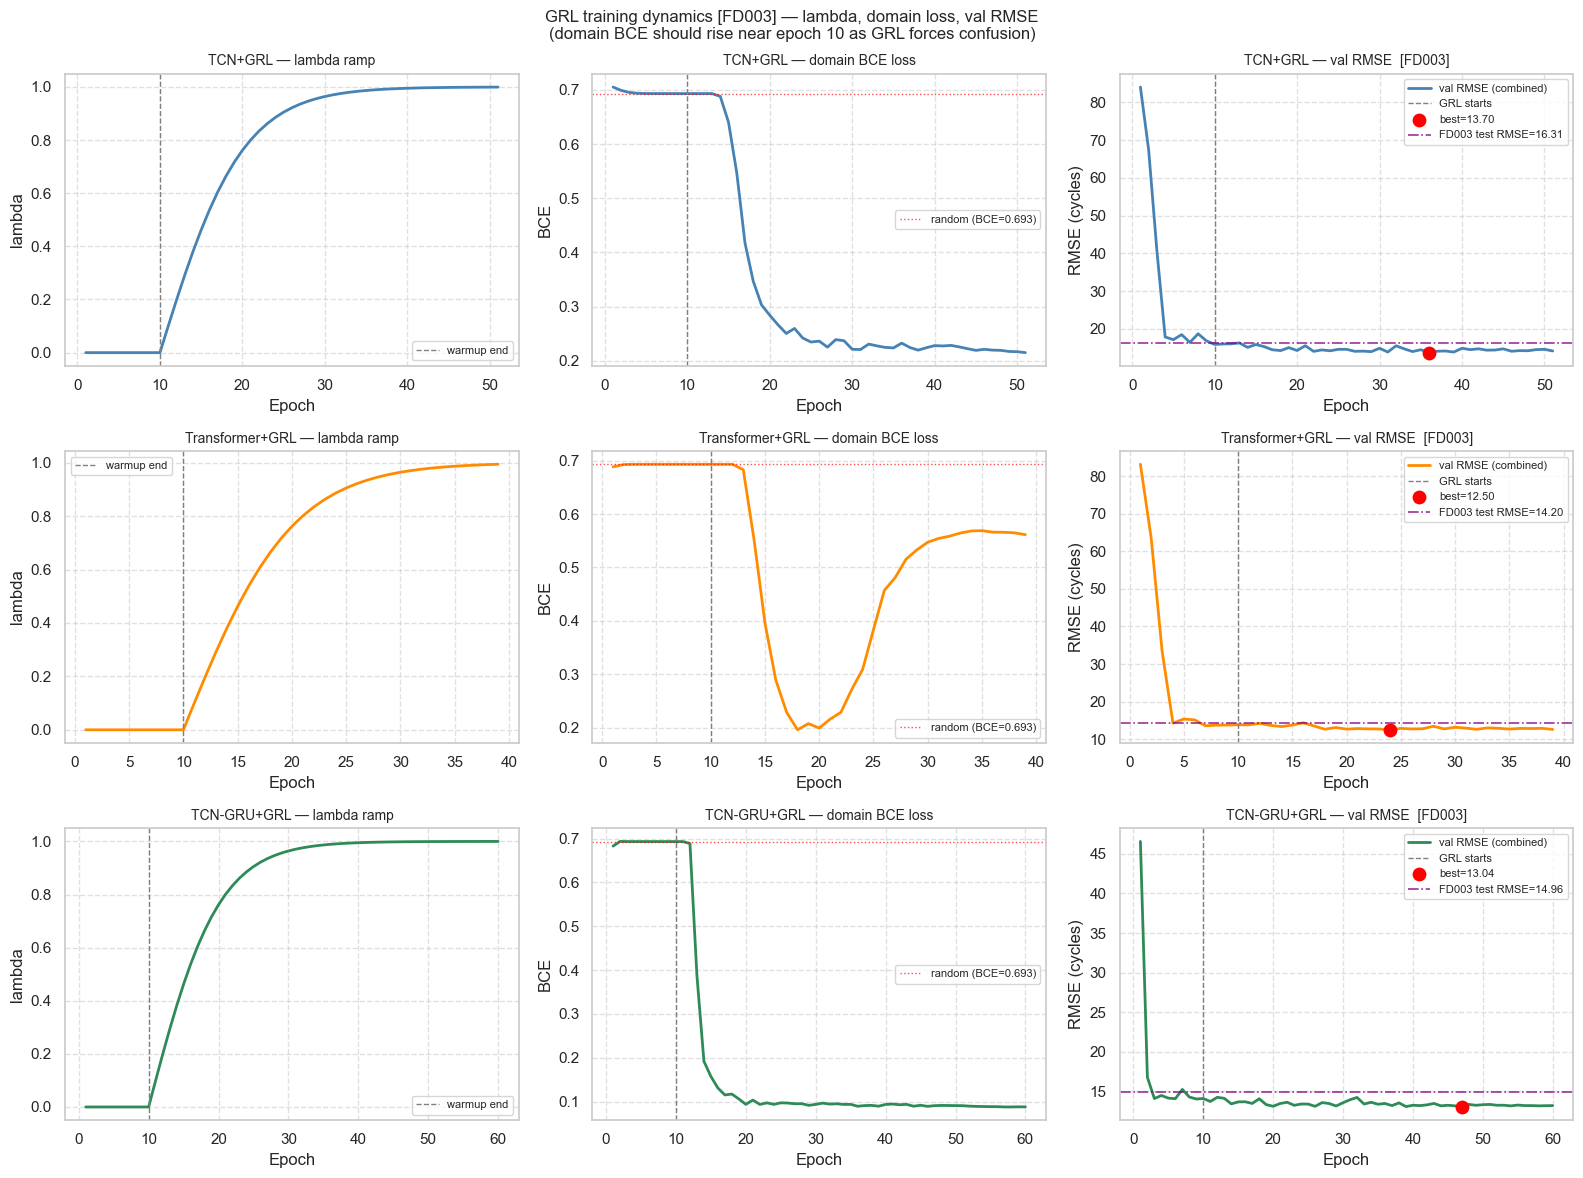

Saved -> figures_v12/v12_grl_dynamics_fd003.png


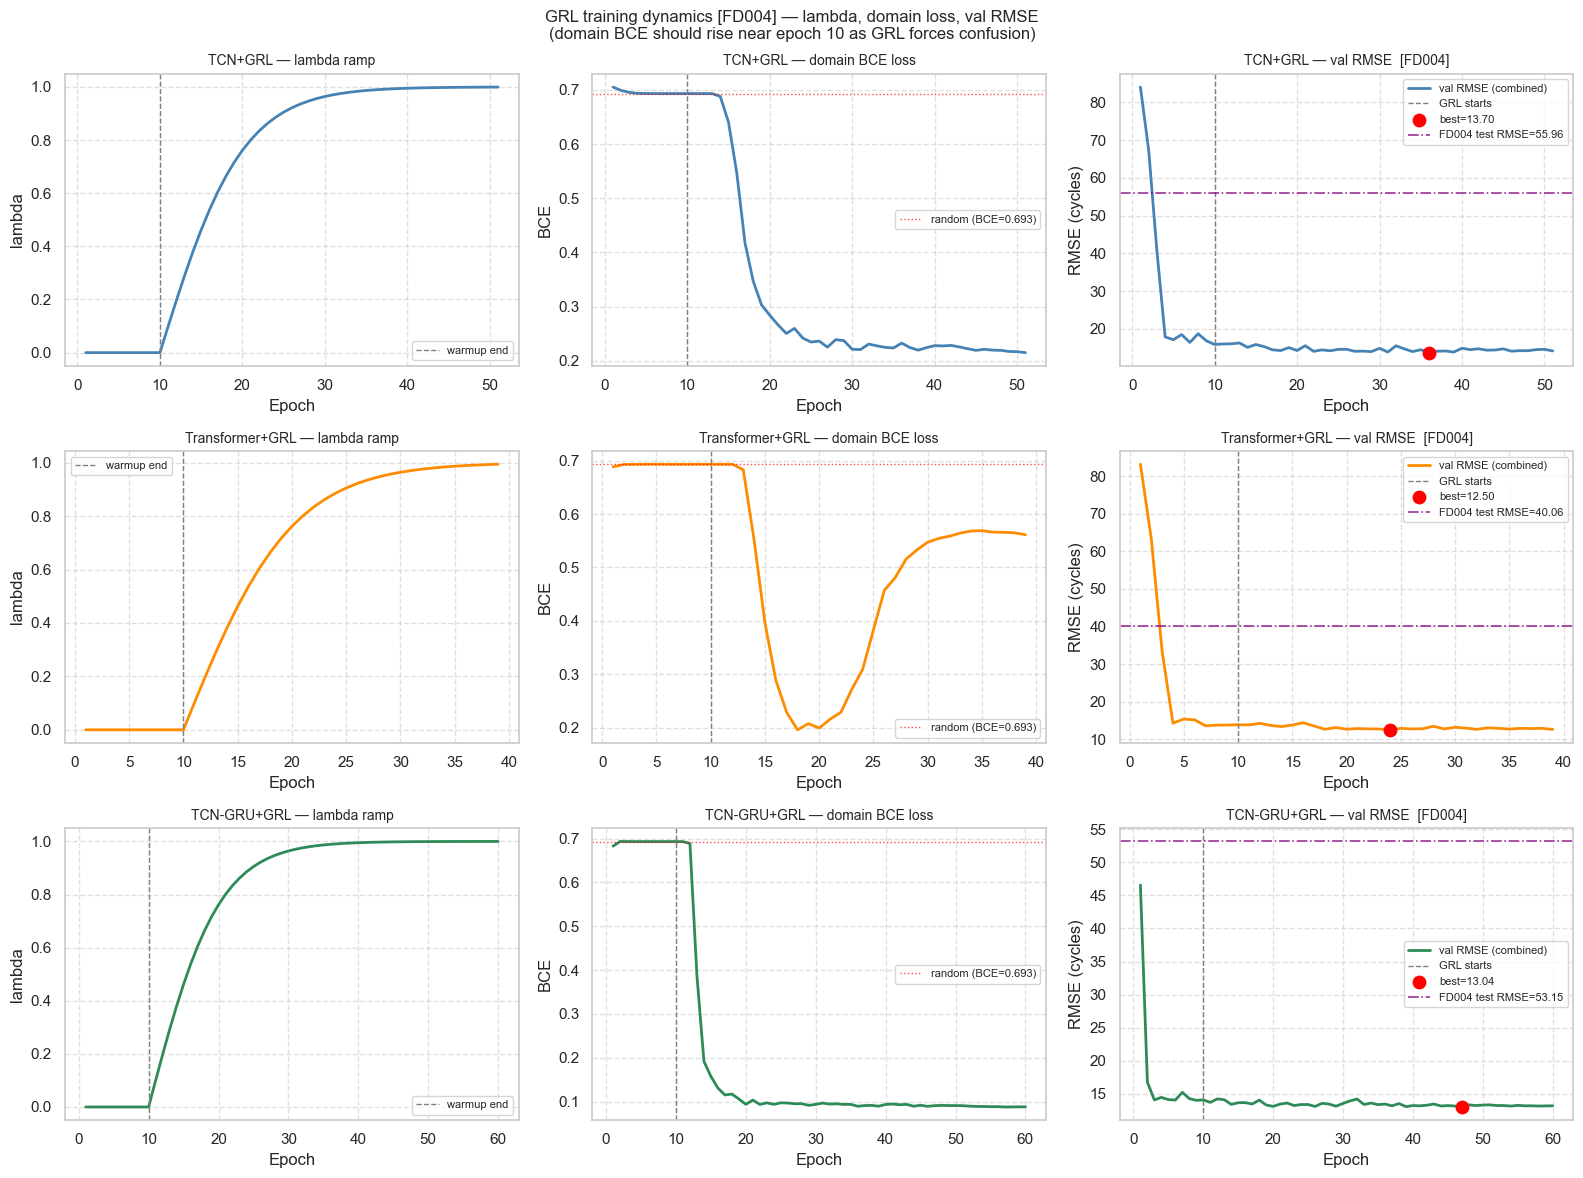

Saved -> figures_v12/v12_grl_dynamics_fd004.png


In [24]:
# One figure per subset: 3 rows (models) × 3 cols (lambda, domain loss, val RMSE)
grl_colors = {'TCN+GRL': 'steelblue', 'Transformer+GRL': 'darkorange', 'TCN-GRU+GRL': 'seagreen'}

for subset in SUBSETS:
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))

    for row, (gname, hist) in enumerate(grl_histories.items()):
        # grl_histories keyed by model name — subset-specific val_rmse needed
        # If your grl_histories already stores per-subset val_rmse, swap below accordingly.
        # As-is, val_rmse column is the combined-val metric from training;
        # we pull per-subset test RMSE from grl_metrics for the scatter annotation.
        color = grl_colors[gname]
        eps   = hist['epoch'].values

        # Col 0: lambda ramp
        ax = axes[row, 0]
        ax.plot(eps, hist['lam'], color=color, lw=2)
        ax.axvline(10, color='gray', linestyle='--', lw=1, label='warmup end')
        ax.set_title(f'{gname} — lambda ramp', fontsize=10)
        ax.set_xlabel('Epoch'); ax.set_ylabel('lambda')
        ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.6)

        # Col 1: domain loss
        ax = axes[row, 1]
        ax.plot(eps, hist['dom_loss'], color=color, lw=2)
        ax.axvline(10, color='gray', linestyle='--', lw=1)
        ax.set_title(f'{gname} — domain BCE loss', fontsize=10)
        ax.set_xlabel('Epoch'); ax.set_ylabel('BCE')
        ax.grid(linestyle='--', alpha=0.6)
        ax.axhline(0.693, color='red', linestyle=':', lw=1, alpha=0.7,
                   label='random (BCE=0.693)')
        ax.legend(fontsize=8)

        # Col 2: val RMSE (combined-val during training) + per-subset test RMSE annotation
        ax = axes[row, 2]
        ax.plot(eps, hist['val_rmse'], color=color, lw=2, label='val RMSE (combined)')
        ax.axvline(10, color='gray', linestyle='--', lw=1, label='GRL starts')
        best_ep = hist.loc[hist['val_rmse'].idxmin(), 'epoch']
        best_vr = hist['val_rmse'].min()
        ax.scatter([best_ep], [best_vr], color='red', s=80, zorder=5,
                   label=f'best={best_vr:.2f}')

        # Annotate with this subset's actual test RMSE
        subset_rmse = grl_metrics.get(gname, {}).get(subset, {}).get('rmse', None)
        if subset_rmse is not None:
            ax.axhline(subset_rmse, color='purple', linestyle='-.', lw=1.2, alpha=0.8,
                       label=f'{subset} test RMSE={subset_rmse:.2f}')

        ax.set_title(f'{gname} — val RMSE  [{subset}]', fontsize=10)
        ax.set_xlabel('Epoch'); ax.set_ylabel('RMSE (cycles)')
        ax.legend(fontsize=8); ax.grid(linestyle='--', alpha=0.6)

    plt.suptitle(
        f'GRL training dynamics [{subset}] — lambda, domain loss, val RMSE\n'
        f'(domain BCE should rise near epoch 10 as GRL forces confusion)',
        fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f'v12_grl_dynamics_{subset.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR}/v12_grl_dynamics_{subset.lower()}.png')

## §17 · Final comparison table

In [19]:
all_results = {}
for name in ['TCN','Transformer','TCN-GRU']:
    all_results[name]         = base_metrics[name]
    all_results[name+'+GRL']  = grl_metrics.get(name+'+GRL', {})

print('='*75)
print('FINAL SUMMARY — v12 (normalization fix applied)')
print('='*75)

rows_rmse = []
rows_score = []
for mname, mres in all_results.items():
    if not mres: continue
    row_r = {'Model': mname}
    row_s = {'Model': mname}
    for s in SUBSETS:
        row_r[s] = f"{mres[s]['rmse']:.2f}"
        row_s[s] = f"{mres[s]['score']:.0f}"
    rows_rmse.append(row_r)
    rows_score.append(row_s)
# Reference rows
rows_rmse.append({'Model':'v12 Transformer (this work — best)',
             'FD001':'14.82','FD002':'24.48','FD003':'14.30','FD004':'24.22'})
rows_rmse.append({'Model':'v9 BiGRU (FD001-only, no DA)',
             'FD001':'14.58','FD002':'59.51','FD003':'—','FD004':'—'})
rows_rmse.append({'Model':'Zheng et al. 2017 (LSTM reference)',
             'FD001':'16.10','FD002':'—','FD003':'—','FD004':'—'})

rmse_df = pd.DataFrame(rows_rmse)
print('\nTest RMSE (lower is better):')
print(rmse_df.to_string(index=False))

score_df = pd.DataFrame(rows_score)
print('\nPHM Asymmetric Score (lower is better — penalises late predictions):')
print(score_df.to_string(index=False))

print('\nGRL delta on target domains (positive = GRL helped):')
for enc_name in ['TCN','Transformer','TCN-GRU']:
    grl_name = enc_name + '+GRL'
    if grl_name not in grl_metrics: continue
    for s in TGT_SUBSETS:
        base_r = base_metrics[enc_name][s]['rmse']
        grl_r  = grl_metrics[grl_name][s]['rmse']
        delta  = base_r - grl_r
        direction = 'BETTER' if delta > 0 else 'WORSE'
        print(f'  {enc_name} on {s}: {base_r:.2f} -> {grl_r:.2f}  '
              f'(delta={delta:+.2f}, {direction})')

FINAL SUMMARY — v12 (normalization fix applied)

Test RMSE (lower is better):
                             Model FD001 FD002 FD003 FD004
                               TCN 15.44 26.20 15.56 24.72
                           TCN+GRL 15.64 55.44 16.31 55.96
                       Transformer 14.82 24.48 14.30 24.22
                   Transformer+GRL 14.09 41.18 14.20 40.06
                           TCN-GRU 15.01 25.36 15.32 24.06
                       TCN-GRU+GRL 15.39 54.72 14.96 53.15
v12 Transformer (this work — best) 14.82 24.48 14.30 24.22
      v9 BiGRU (FD001-only, no DA) 14.58 59.51     —     —
Zheng et al. 2017 (LSTM reference) 16.10     —     —     —

PHM Asymmetric Score (lower is better — penalises late predictions):
          Model FD001   FD002 FD003   FD004
            TCN   431   10813   502    5319
        TCN+GRL   441  420143   711  245084
    Transformer   399    5914   330    5146
Transformer+GRL   313  253885   408  277850
        TCN-GRU   404   10661   442    340

/var/folders/p6/wn2qm7j91zx42_zg8m02n1qw0000gn/T/ipykernel_46567/2304097584.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


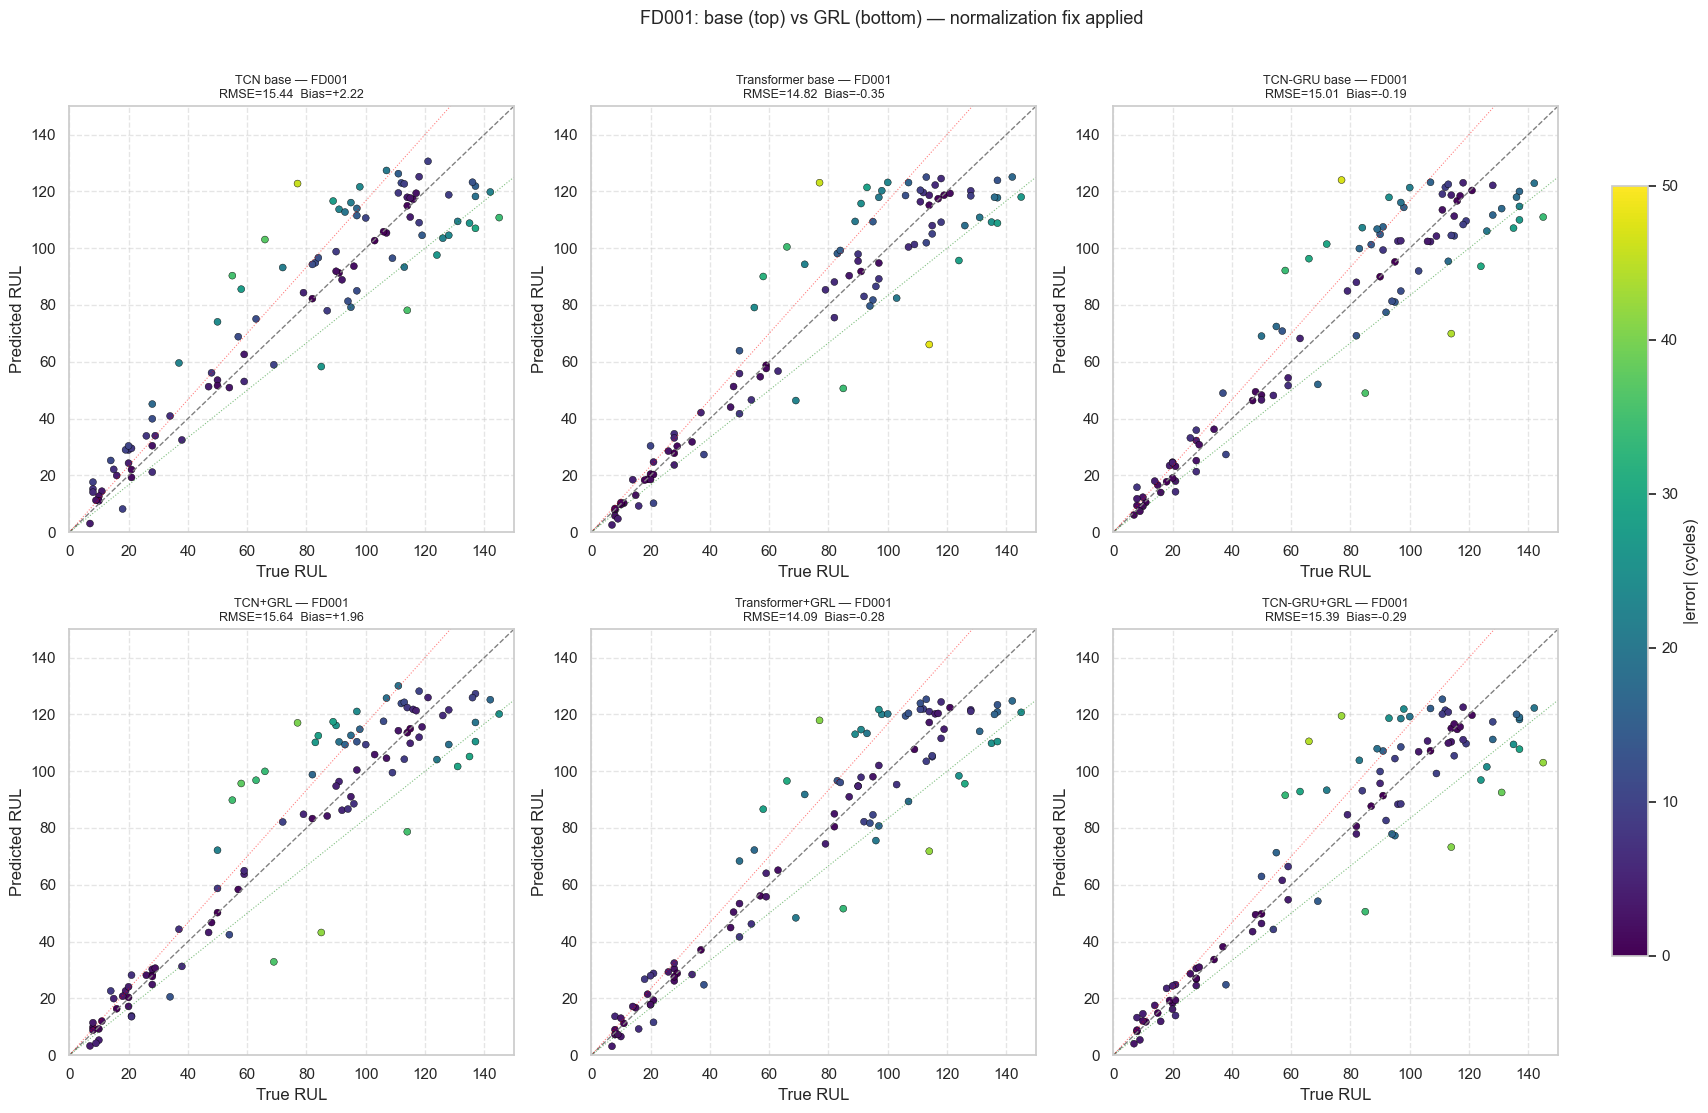

Saved -> figures_v12/v12_base_vs_grl_fd001.png


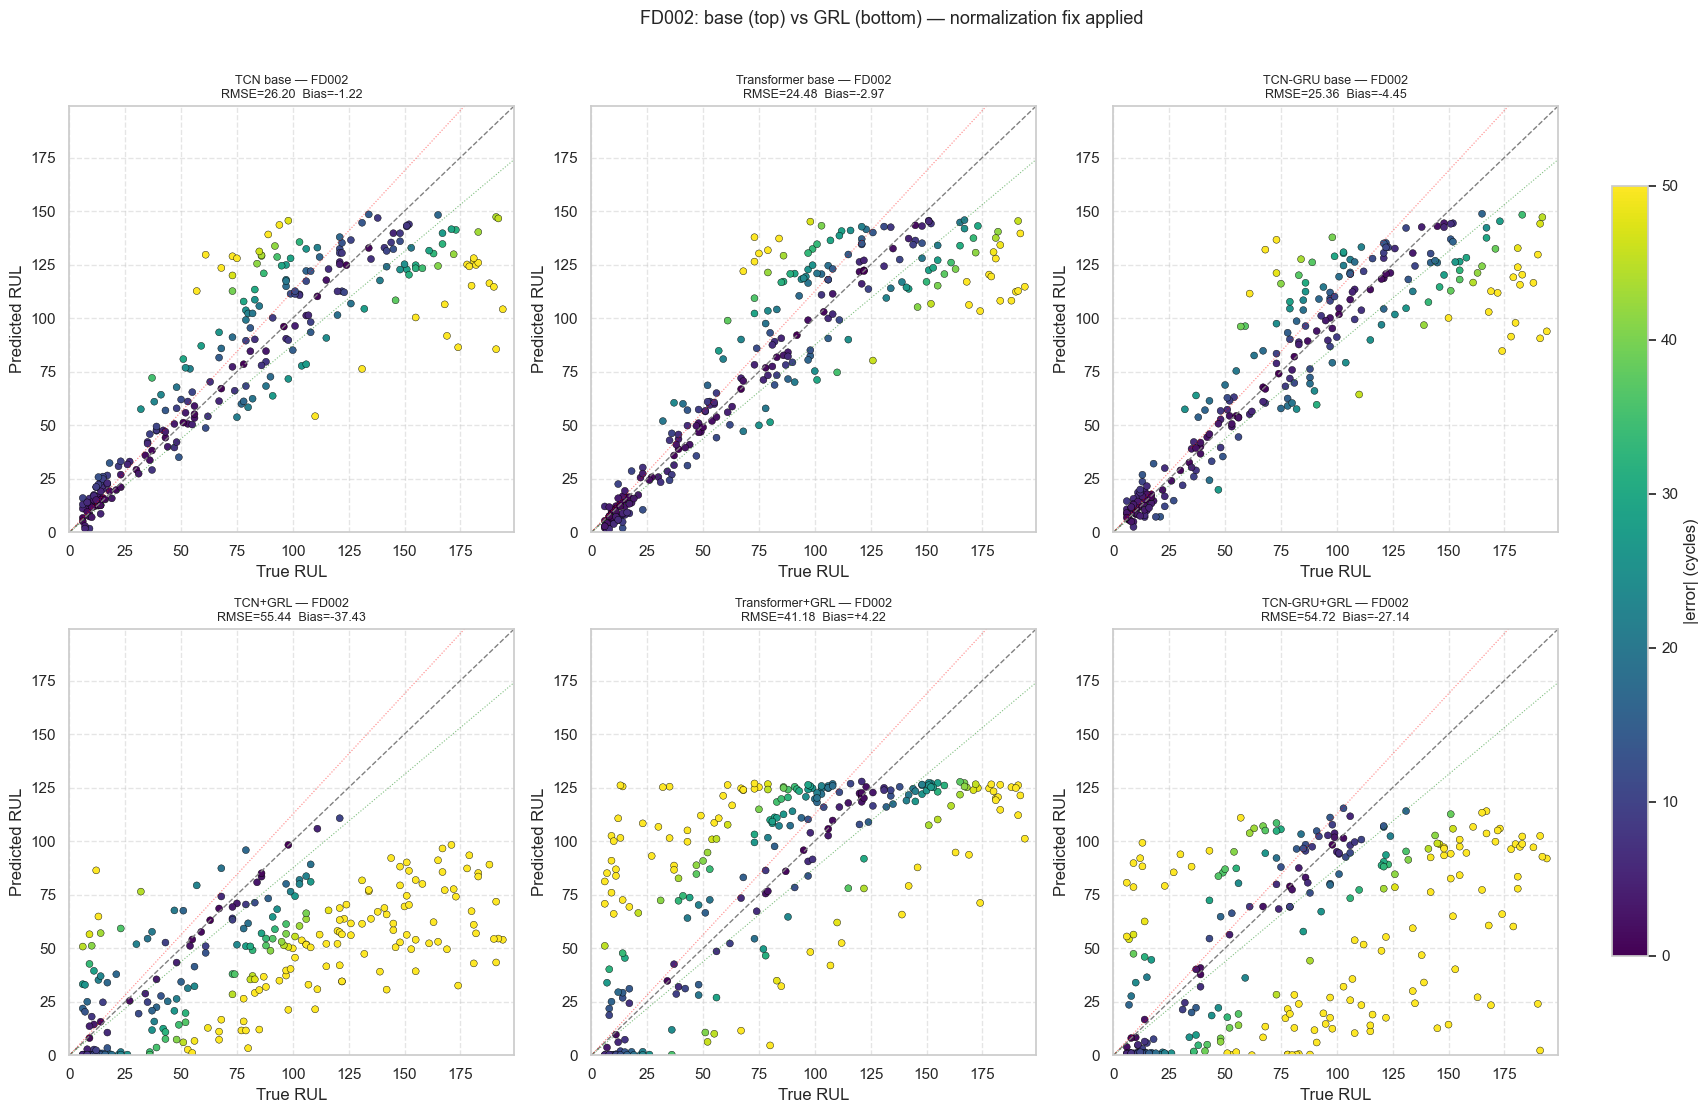

Saved -> figures_v12/v12_base_vs_grl_fd002.png


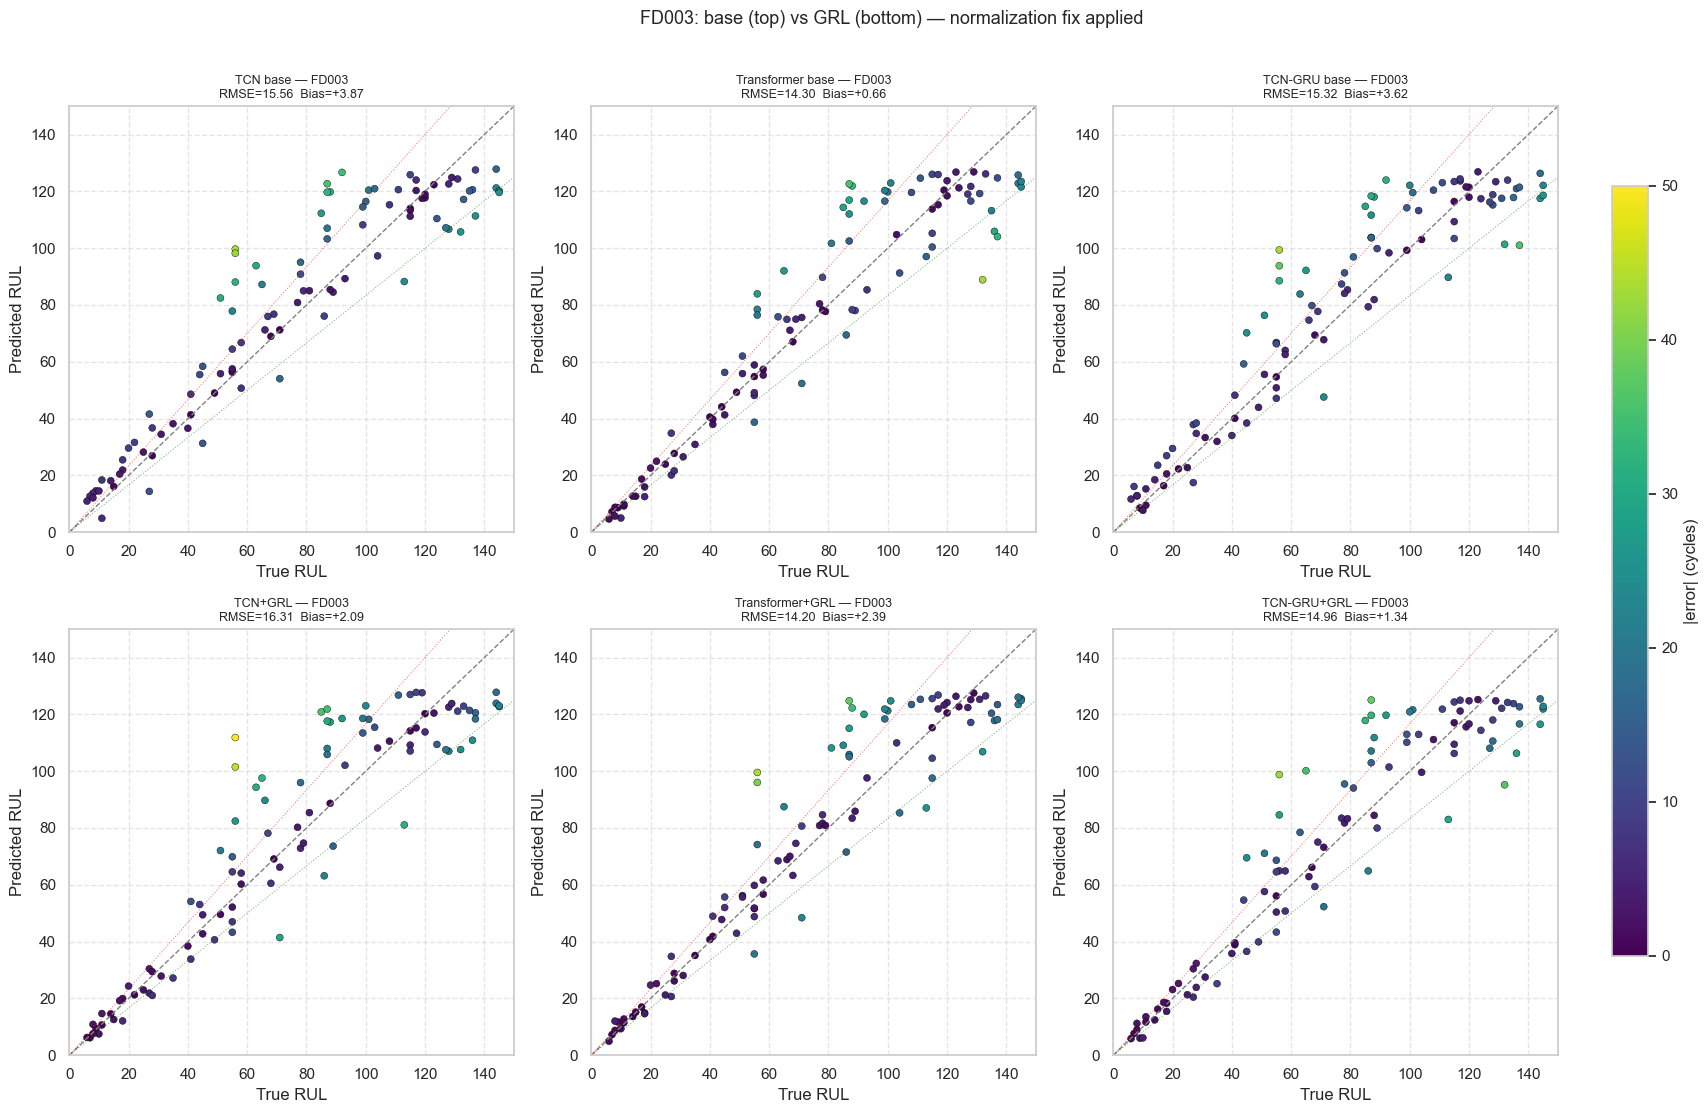

Saved -> figures_v12/v12_base_vs_grl_fd003.png


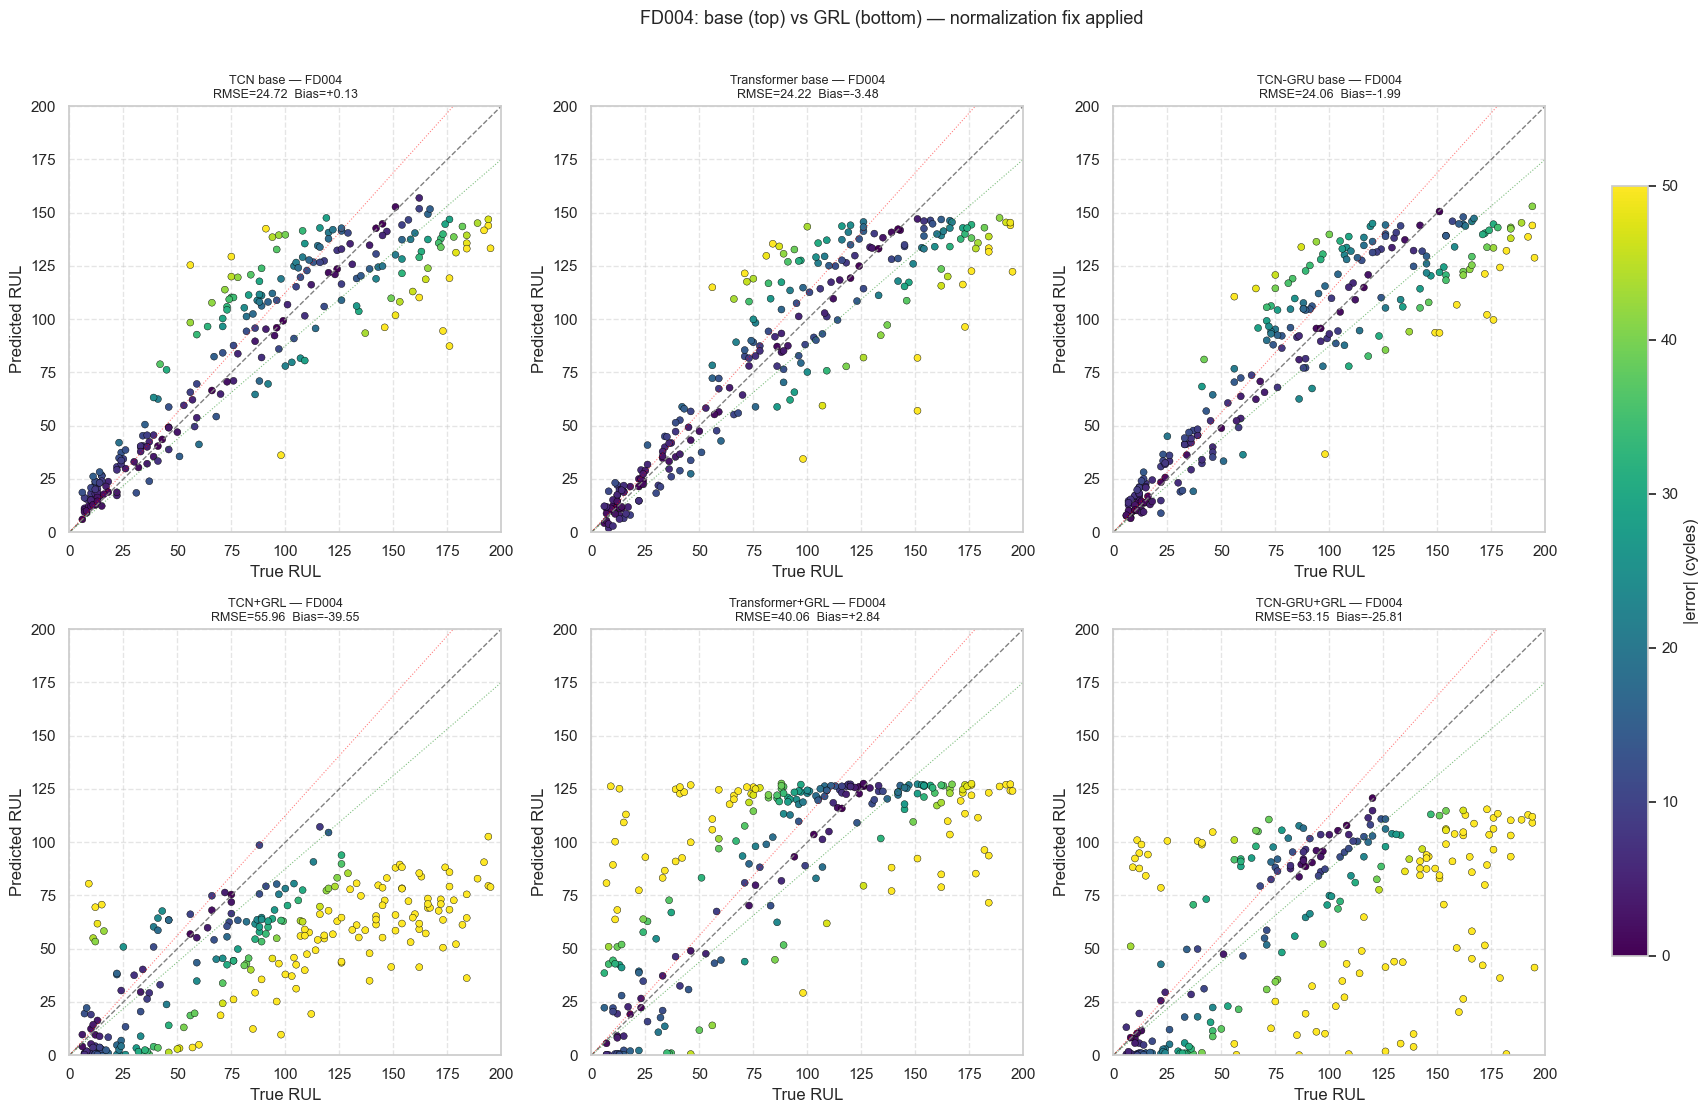

Saved -> figures_v12/v12_base_vs_grl_fd004.png


In [22]:
# ── Scatter: base vs GRL for all 4 datasets (FD001–FD004) ──────────────────────

def plot_scatter(ax, y_true, y_pred_raw, title):
    yp  = np.clip(y_pred_raw, 0, None)
    err = np.abs(yp - y_true)
    lim = max(y_true.max(), yp.max()) + 5
    ax.plot([0, lim], [0, lim],      '--', color='gray',  lw=1)
    ax.plot([0, lim], [0, lim - 25], ':',  color='green', lw=0.8, alpha=0.5)
    ax.plot([0, lim], [0, lim + 25], ':',  color='red',   lw=0.8, alpha=0.5)
    sc = ax.scatter(y_true, yp, c=err, cmap='viridis',
                    s=25, edgecolor='black', linewidth=0.3, vmin=0, vmax=50)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('True RUL'); ax.set_ylabel('Predicted RUL')
    rmse = math.sqrt(np.mean((yp - y_true) ** 2))
    bias = float((yp - y_true).mean())
    ax.set_title(f'{title}\nRMSE={rmse:.2f}  Bias={bias:+.2f}', fontsize=9)
    ax.grid(linestyle='--', alpha=0.5)
    return sc

grl_enc_map = [
    ('TCN+GRL',         lambda: TCN(len(USE_SENSORS), n_channels=32, dropout=0.2)),
    ('Transformer+GRL', lambda: LightweightTransformer(len(USE_SENSORS), d_model=64, nhead=4,
                                                       dim_feedforward=128, dropout=0.1)),
    ('TCN-GRU+GRL',     lambda: TCNGRUHybrid(len(USE_SENSORS), tcn_channels=32,
                                              gru_hidden=64, dropout=0.2)),
]

# Pre-load base models (they are already in model_specs after training)
# Re-instantiate GRL models fresh for each figure to avoid state leakage
for subset in SUBSETS:   # ['FD001', 'FD002', 'FD003', 'FD004']
    yt = test_ruls[subset]

    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    plt.subplots_adjust(right=0.88)

    # ── Row 0: base models ────────────────────────────────────────────────────
    for col, (mname, model) in enumerate(model_specs):
        raw = run_inference(model, test_windows[subset], Device)
        sc  = plot_scatter(axes[0, col], yt, raw, f'{mname} base — {subset}')

    # ── Row 1: GRL models ─────────────────────────────────────────────────────
    for col, (grl_label, make_encoder) in enumerate(grl_enc_map):
        safe = grl_label.lower().replace('+', '_').replace('-', '_')
        gm   = GRLWrapper(make_encoder()).to(Device)
        sd   = torch.load(CKPT_DIR / f'grl_{safe}.pt',
                          map_location=Device, weights_only=False)
        gm.load_state_dict(sd['model'])
        raw  = run_inference_dann(gm, test_windows[subset], Device)
        sc   = plot_scatter(axes[1, col], yt, raw, f'{grl_label} — {subset}')

    # ── Colorbar on its own axes (no axis stealing) ───────────────────────────
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
    fig.colorbar(sc, cax=cax, label='|error| (cycles)')

    plt.suptitle(f'{subset}: base (top) vs GRL (bottom) — normalization fix applied',
                 fontsize=13, y=1.01)
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.savefig(FIG_DIR / f'v12_base_vs_grl_{subset.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {FIG_DIR}/v12_base_vs_grl_{subset.lower()}.png')

In [30]:
final_results = {
    'base': {n: {s: m for s,m in v.items()} for n,v in base_metrics.items()},
    'grl':  {n: {s: m for s,m in v.items()} for n,v in grl_metrics.items()},
    'config': {
        'window': W, 'rul_clips': RUL_CLIPS, 'n_features': len(USE_SENSORS),
        'normalization': 'regression-based + settings clamping (v12 fix)',
        'loss': 'asymmetric_mse(1.3) + 0.3*state_mse',
    }
}
with open(CKPT_DIR/'v12_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)

print(f'Saved {CKPT_DIR}/v12_results.json')
print(f'Figures: {sorted([p.name for p in FIG_DIR.glob("*.png")])}')
print(f'Checkpoints: {len(list(CKPT_DIR.glob("*.pt")))} .pt files')

Saved checkpoints_v12/v12_results.json
Figures: ['v12_attention_heatmap.png', 'v12_attention_heatmap_fd001.png', 'v12_attention_heatmap_fd002.png', 'v12_attention_heatmap_fd003.png', 'v12_attention_heatmap_fd004.png', 'v12_base_vs_grl_fd001.png', 'v12_base_vs_grl_fd002.png', 'v12_base_vs_grl_fd003.png', 'v12_base_vs_grl_fd004.png', 'v12_error_by_bucket.png', 'v12_error_by_bucket_fd001.png', 'v12_error_by_bucket_fd002.png', 'v12_error_by_bucket_fd003.png', 'v12_error_by_bucket_fd004.png', 'v12_grl_dynamics.png', 'v12_grl_dynamics_fd001.png', 'v12_grl_dynamics_fd002.png', 'v12_grl_dynamics_fd003.png', 'v12_grl_dynamics_fd004.png', 'v12_rul_trajectories.png', 'v12_rul_trajectories_fd001.png', 'v12_rul_trajectories_fd002.png', 'v12_rul_trajectories_fd003.png', 'v12_rul_trajectories_fd004.png', 'v12_sensor_correlation.png', 'v12_training_curves.png', 'v12_tsne.png']
Checkpoints: 6 .pt files
